# Sleep Quality Prediction: Classification vs Regression Analysis

This notebook analyzes the relationship between screen time/technology usage and **sleep quality**. We'll compare two modeling approaches:
- **Regression**: Treating sleep quality as a continuous ordinal variable
- **Classification**: Treating sleep quality as discrete categories

**Target Variable**: Sleep Quality (1-10 scale for Dataset 1, 1-7 scale for Dataset 2)

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    classification_report, confusion_matrix, accuracy_score
)

# Regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

# Classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Set display options
pd.set_option('display.max_columns', None)
np.random.seed(42)

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.3.4
Pandas version: 2.3.3


# 1. Loading Datasets

## Dataset 1: Daily Technology Usage and Mental Health

This dataset offers insights into how daily technology usage, including social media and screen time, impacts mental health. It captures various behavioral patterns and their correlations with mental health indicators like stress levels, sleep quality, and productivity.

In [2]:
df_dataset1 = pd.read_csv('DataSets/dataset1.csv', header=None)
df_dataset1.columns = ['User.ID', 'Age', 'Gender', 'Country', 'Device.Type', 'Daily.Screen.Time', 
           'Social.Media.Hours', 'Work.Screen.Hours', 'Gaming.Hours', 'Sleep.Hours', 
           'Sleep.Quality', 'Stress.Level', 'Physical.Activity.Min', 'Productivity.Score', 
           'Mental.Health.Status']
df_dataset1.sample(5)

,User.ID,Age,Gender,Country,Device.Type,Daily.Screen.Time,Social.Media.Hours,Work.Screen.Hours,Gaming.Hours,Sleep.Hours,Sleep.Quality,Stress.Level,Physical.Activity.Min,Productivity.Score,Mental.Health.Status
521,521,47,Female,Germany,Tablet,6.1,4.2,5.1,0.2,6.0,5,10,60,4,Healthy
941,941,53,Male,USA,Tablet,8.4,3.5,3.2,2.8,7.6,3,2,53,1,Moderate Issues
741,741,35,Male,UK,Phone,4.7,1.1,0.5,0.5,5.9,1,10,86,2,Healthy
980,980,41,Male,Canada,Tablet,3.3,1.0,3.0,0.5,7.6,3,6,103,1,Healthy
411,411,23,Female,USA,Phone,9.7,1.8,7.8,0.6,8.7,2,5,27,8,Healthy


## Dataset 2: Phone Usage and Sleep Quality

This dataset contains information about daily phone usage patterns and their relationship with sleep quality. Includes daytime use, pre-bed use, and post-bed use measurements.

In [3]:
df_dataset2 = pd.read_csv('DataSets/Dataset2/phone.csv', header=None)
df_dataset2.columns = ['user_id', 'study_day', 'daytime_use', 'prebed_use', 'postbed_use', 'sleep_qual']
df_dataset2.sample(20)


,user_id,study_day,daytime_use,prebed_use,postbed_use,sleep_qual
635,68,5,-999,-999,-999,-999
949,104,4,8.760555555555555,0.9197222222222222,0.42027777777777775,6
2661,317,15,-999,-999,-999,-999
17,1,17,12.057777777777778,0,0,4
2798,333,5,-999,-999,-999,-999
879,98,18,-999,-999,-999,-999
134,20,8,-999,-999,-999,-999
1396,151,10,-999,-999,-999,-999
3061,365,16,5.456388888888889,1,1.618888888888889,4
2910,347,12,-999,-999,-999,-999


# 2. Data Cleaning and Preprocessing

## Dataset 1

In [4]:
# Basic dataset information
df_dataset1.info()
print(f"\nMissing values:\n{df_dataset1.isnull().sum()}")
print(f"\nShape: {df_dataset1.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   User.ID                1001 non-null   object
 1   Age                    1001 non-null   object
 2   Gender                 1001 non-null   object
 3   Country                1001 non-null   object
 4   Device.Type            1001 non-null   object
 5   Daily.Screen.Time      1001 non-null   object
 6   Social.Media.Hours     1001 non-null   object
 7   Work.Screen.Hours      1001 non-null   object
 8   Gaming.Hours           1001 non-null   object
 9   Sleep.Hours            1001 non-null   object
 10  Sleep.Quality          1001 non-null   object
 11  Stress.Level           1001 non-null   object
 12  Physical.Activity.Min  1001 non-null   object
 13  Productivity.Score     1001 non-null   object
 14  Mental.Health.Status   1001 non-null   object
dtypes: object(15)
memory 

In [5]:
# Statistical summary
df_dataset1.describe()

,User.ID,Age,Gender,Country,Device.Type,Daily.Screen.Time,Social.Media.Hours,Work.Screen.Hours,Gaming.Hours,Sleep.Hours,Sleep.Quality,Stress.Level,Physical.Activity.Min,Productivity.Score,Mental.Health.Status
count,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001,1001
unique,1001,50,4,7,5,99,69,92,51,68,11,11,121,11,4
top,User.ID,41,Female,Germany,Laptop,6.3,0.0,0.0,0.1,6.5,4,9,78,1,Healthy
freq,1,30,505,186,373,32,43,27,91,44,110,110,18,111,614


### Clean Dataset 1

Steps:
1. Remove header row if present
2. Filter to Phone/Tablet devices only
3. Drop unnecessary columns (User.ID, Country, Device.Type)
4. Convert data types
5. Handle missing values

In [6]:
# Remove header row if it exists in the data
df_dataset1 = df_dataset1[df_dataset1['Sleep.Quality'] != 'Sleep.Quality'].copy()

# Check device types
print("Device types:")
print(df_dataset1['Device.Type'].value_counts())

# Filter to Phone and Tablet only
df_dataset1 = df_dataset1[df_dataset1['Device.Type'].isin(['Phone', 'Tablet'])].copy()
print(f"\nRows after filtering: {len(df_dataset1)}")

Device types:
Device.Type
Laptop     373
Phone      368
Tablet     163
Desktop     96
Name: count, dtype: int64

Rows after filtering: 531


In [7]:
# Drop unnecessary columns and convert data types
df_dataset1 = df_dataset1.drop(columns=['User.ID', 'Country', 'Device.Type'])

# Convert numeric columns
numeric_cols = ['Age', 'Daily.Screen.Time', 'Social.Media.Hours', 'Work.Screen.Hours', 
                'Gaming.Hours', 'Sleep.Hours', 'Sleep.Quality', 'Stress.Level', 
                'Physical.Activity.Min', 'Productivity.Score']

for col in numeric_cols:
    df_dataset1[col] = pd.to_numeric(df_dataset1[col], errors='coerce')

# Remove any rows with NaN values in numeric columns
df_dataset1 = df_dataset1.dropna(subset=numeric_cols)

print(f"Final shape: {df_dataset1.shape}")
print(f"\nData types:\n{df_dataset1.dtypes}")

Final shape: (531, 12)

Data types:
Age                        int64
Gender                    object
Daily.Screen.Time        float64
Social.Media.Hours       float64
Work.Screen.Hours        float64
Gaming.Hours             float64
Sleep.Hours              float64
Sleep.Quality              int64
Stress.Level               int64
Physical.Activity.Min      int64
Productivity.Score         int64
Mental.Health.Status      object
dtype: object


### Explore Sleep Quality Distribution

Sleep Quality Distribution (Dataset 1):
Sleep.Quality
1     53
2     67
3     48
4     66
5     53
6     49
7     49
8     46
9     52
10    48
Name: count, dtype: int64


C:\Users\aleix\AppData\Local\Temp\ipykernel_3244\1568574024.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_dataset1[df_dataset1['Sleep.Quality'] == i]['Daily.Screen.Time'].dropna()


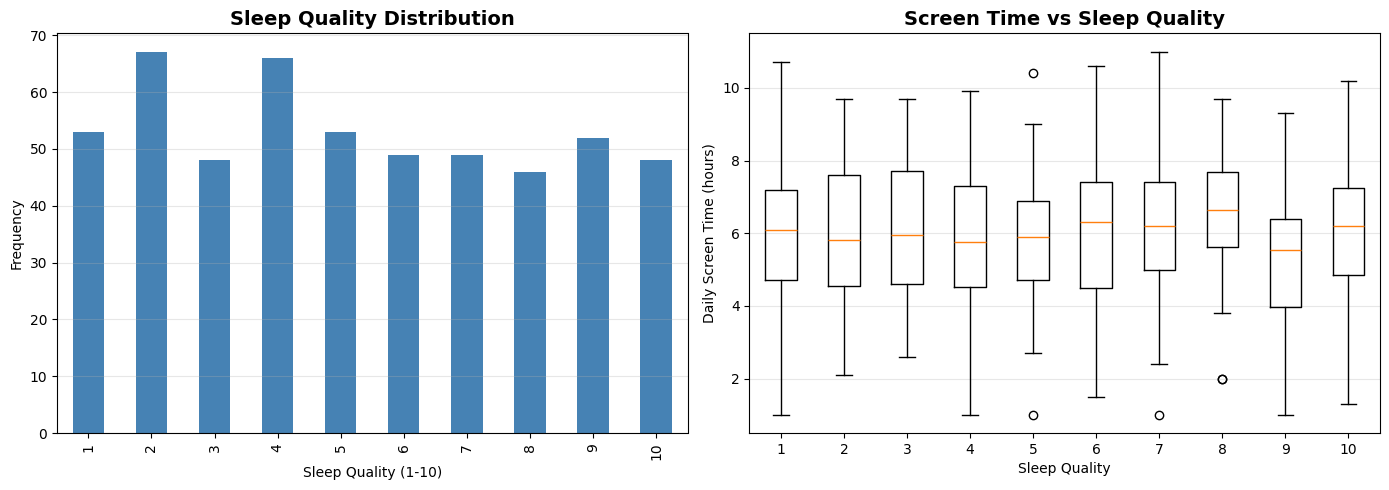

In [8]:
# Analyze sleep quality distribution
print("Sleep Quality Distribution (Dataset 1):")
print(df_dataset1['Sleep.Quality'].value_counts().sort_index())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df_dataset1['Sleep.Quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Sleep Quality Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sleep Quality (1-10)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Box plot with screen time
axes[1].boxplot([df_dataset1[df_dataset1['Sleep.Quality'] == i]['Daily.Screen.Time'].dropna() 
                 for i in sorted(df_dataset1['Sleep.Quality'].unique())],
                labels=sorted(df_dataset1['Sleep.Quality'].unique()))
axes[1].set_title('Screen Time vs Sleep Quality', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sleep Quality')
axes[1].set_ylabel('Daily Screen Time (hours)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Preview cleaned dataset 1
print("Cleaned Dataset 1 columns:")
print(df_dataset1.columns.tolist())
print(f"\nSample data:")
df_dataset1.sample(5)

Cleaned Dataset 1 columns:
['Age', 'Gender', 'Daily.Screen.Time', 'Social.Media.Hours', 'Work.Screen.Hours', 'Gaming.Hours', 'Sleep.Hours', 'Sleep.Quality', 'Stress.Level', 'Physical.Activity.Min', 'Productivity.Score', 'Mental.Health.Status']

Sample data:


,Age,Gender,Daily.Screen.Time,Social.Media.Hours,Work.Screen.Hours,Gaming.Hours,Sleep.Hours,Sleep.Quality,Stress.Level,Physical.Activity.Min,Productivity.Score,Mental.Health.Status
924,43,Male,5.7,3.6,2.3,0.3,6.4,9,9,104,6,Healthy
579,38,Female,5.9,2.9,1.8,0.0,7.4,10,8,105,1,Moderate Issues
544,17,Male,5.5,2.2,6.4,1.3,4.9,9,2,63,9,Healthy
525,27,Female,4.6,0.2,5.9,0.7,5.6,4,6,57,7,Healthy
706,33,Male,8.2,3.2,5.3,0.5,6.6,7,10,115,10,Healthy


### Clean Dataset 2

Steps:
1. Remove header row if present
2. Remove missing values (-999)
3. Convert usage times to minutes
4. Drop unnecessary columns

In [10]:
# Check initial state
print("Initial shape:", df_dataset2.shape)
print("\nSample before cleaning:")
df_dataset2.head(10)

Initial shape: (3256, 6)

Sample before cleaning:


,user_id,study_day,daytime_use,prebed_use,postbed_use,sleep_qual
0,user_id,study_day,daytime_use,prebed_use,postbed_use,sleep_qual
1,1,1,9.06611111111111,0.20083333333333334,0,4
2,1,2,-999,-999,-999,-999
3,1,3,7.0925,0.30722222222222223,0,5
4,1,4,10.292222222222222,0.1325,0,5
5,1,5,11.598888888888888,0.0811111111111111,0.2033333333333333,7
6,1,6,12.795277777777779,0,0.5975,5
7,1,7,6.9238888888888885,0.025,0,5
8,1,8,-999,-999,-999,-999
9,1,9,-999,-999,-999,-999


In [11]:
# Remove header row if present
df_dataset2 = df_dataset2[df_dataset2['sleep_qual'] != 'sleep_qual'].copy()

# Remove missing values (-999)
df_dataset2 = df_dataset2[df_dataset2["daytime_use"] != "-999"].copy()
df_dataset2 = df_dataset2[df_dataset2["prebed_use"] != "-999"].copy()
df_dataset2 = df_dataset2[df_dataset2["postbed_use"] != "-999"].copy()
df_dataset2 = df_dataset2[df_dataset2["sleep_qual"] != "-999"].copy()

print(f"Rows after removing missing values: {len(df_dataset2)}")

Rows after removing missing values: 1806


In [12]:
# Drop ID columns
df_dataset2 = df_dataset2.drop(columns=['user_id', 'study_day'])

print("Remaining columns:", df_dataset2.columns.tolist())

Remaining columns: ['daytime_use', 'prebed_use', 'postbed_use', 'sleep_qual']


### Convert time values and prepare sleep quality

In [13]:
# Convert all columns to numeric
usage_cols = ['daytime_use', 'prebed_use', 'postbed_use']

for col in usage_cols:
    df_dataset2[col] = pd.to_numeric(df_dataset2[col], errors='coerce')

# Remove rows with invalid data
df_dataset2 = df_dataset2.dropna(subset=usage_cols)

# Convert from hours to minutes and round
df_dataset2[usage_cols] = (df_dataset2[usage_cols] * 60).round(0).astype(int)

# Convert sleep quality to numeric
df_dataset2['sleep_qual'] = pd.to_numeric(df_dataset2['sleep_qual'], errors='coerce')
df_dataset2 = df_dataset2.dropna(subset=['sleep_qual'])

print(f"Final shape: {df_dataset2.shape}")
print(f"Data types:\n{df_dataset2.dtypes}")

Final shape: (1806, 4)
Data types:
daytime_use    int64
prebed_use     int64
postbed_use    int64
sleep_qual     int64
dtype: object


Sleep Quality Distribution (Dataset 2):
sleep_qual
1     19
2     12
3     60
4    367
5    317
6    505
7    526
Name: count, dtype: int64

Range: 1 to 7


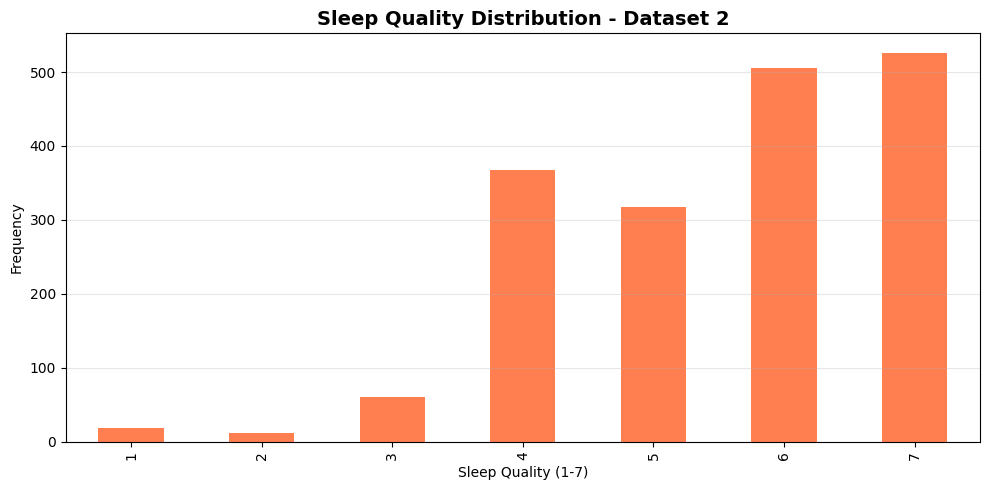

,daytime_use,prebed_use,postbed_use,sleep_qual
583,262,0,16,7
3197,549,21,5,6
426,88,0,4,6
1654,390,32,0,3
1677,509,0,1,6


In [14]:
# Explore sleep quality distribution in dataset 2
print("Sleep Quality Distribution (Dataset 2):")
print(df_dataset2['sleep_qual'].value_counts().sort_index())
print(f"\nRange: {df_dataset2['sleep_qual'].min()} to {df_dataset2['sleep_qual'].max()}")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
df_dataset2['sleep_qual'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Sleep Quality Distribution - Dataset 2', fontsize=14, fontweight='bold')
ax.set_xlabel('Sleep Quality (1-7)')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Sample
df_dataset2.sample(5)

# 3. Exploratory Data Analysis: Investigating Predictive Power

**Research Question**: Do the features in this dataset have sufficient predictive power for sleep quality?

We'll conduct comprehensive statistical tests to determine if the data can support predictive modeling.

### Correlation Analysis - Dataset 1

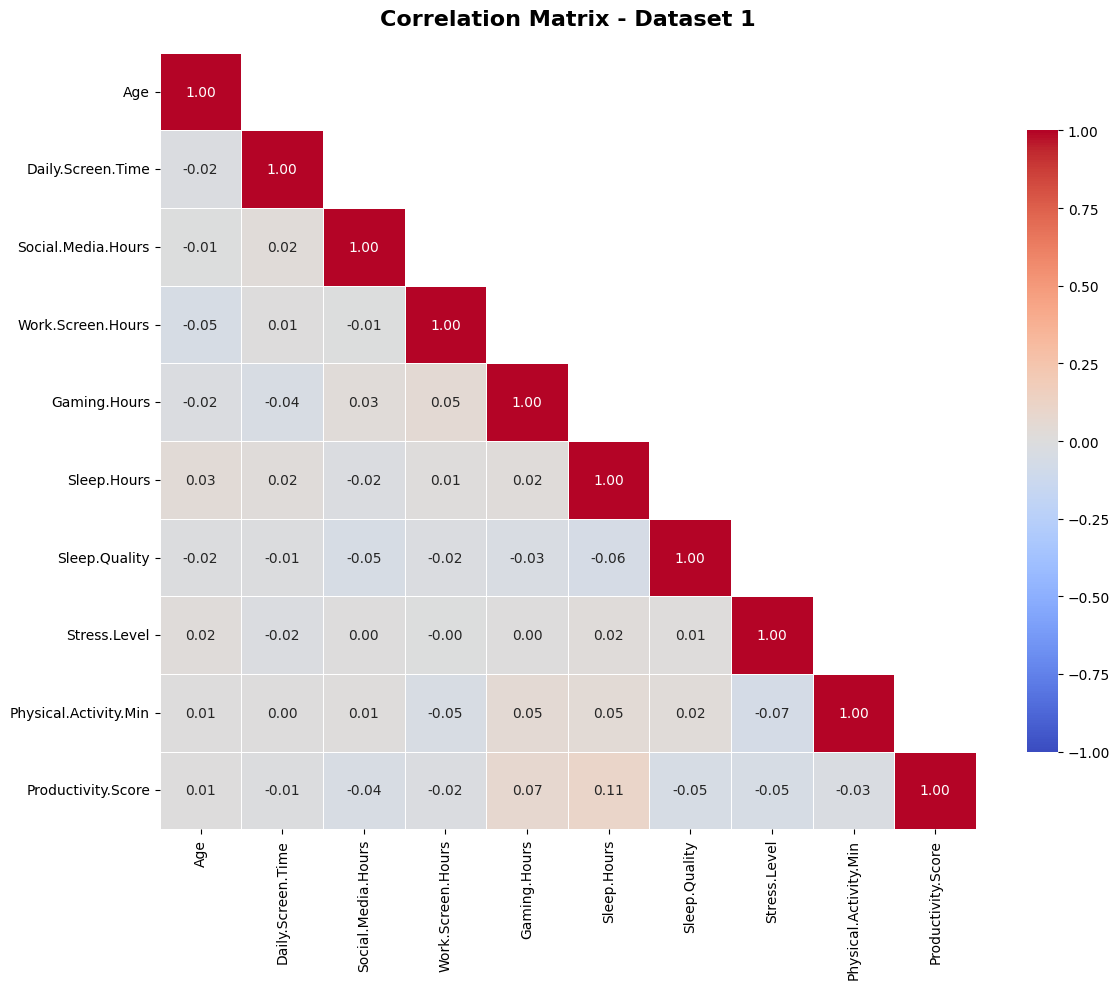

Correlations with Sleep Quality:
Sleep.Quality            1.000000
Physical.Activity.Min    0.023739
Stress.Level             0.010750
Daily.Screen.Time       -0.011789
Age                     -0.015480
Work.Screen.Hours       -0.019926
Gaming.Hours            -0.033071
Productivity.Score      -0.049381
Social.Media.Hours      -0.049701
Sleep.Hours             -0.060473
Name: Sleep.Quality, dtype: float64


In [15]:
# Correlation matrix for numeric features
numeric_features = df_dataset1.select_dtypes(include=[np.number]).columns.tolist()

# Remove categorical-looking numerics if any
corr_matrix = df_dataset1[numeric_features].corr()

# Plot
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Dataset 1', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlations with Sleep Quality
print("Correlations with Sleep Quality:")
print(corr_matrix['Sleep.Quality'].sort_values(ascending=False))

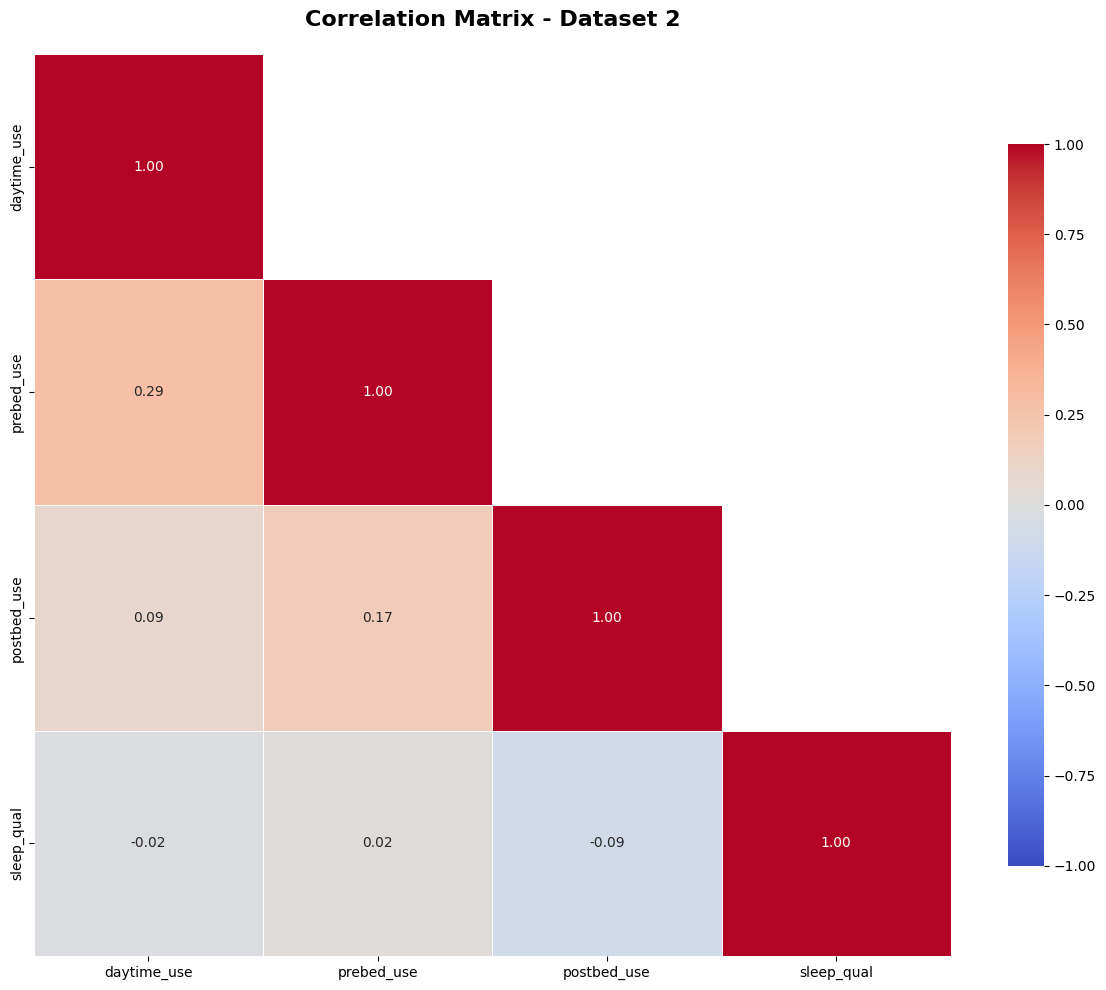

Correlations with Sleep Quality:
Sleep.Quality            1.000000
Physical.Activity.Min    0.023739
Stress.Level             0.010750
Daily.Screen.Time       -0.011789
Age                     -0.015480
Work.Screen.Hours       -0.019926
Gaming.Hours            -0.033071
Productivity.Score      -0.049381
Social.Media.Hours      -0.049701
Sleep.Hours             -0.060473
Name: Sleep.Quality, dtype: float64


In [17]:
# Correlation matrix for Dataset 2
corr_matrix_2 = df_dataset2.corr()

# Plot
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_2, dtype=bool), k=1)
sns.heatmap(corr_matrix_2, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Dataset 2', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlations with Sleep Quality
print("Correlations with Sleep Quality:")
print(corr_matrix['Sleep.Quality'].sort_values(ascending=False))

## Statistical Tests: Does Screen Time Predict Sleep Quality?

Let's test whether our features have statistically significant relationships with sleep quality.

In [19]:
from scipy import stats

# ANOVA test: Does sleep quality differ across screen time groups?
# Group screen time into quartiles
df_dataset1['ScreenTime_Quartile'] = pd.qcut(df_dataset1['Daily.Screen.Time'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

# Get sleep quality for each quartile
groups = [df_dataset1[df_dataset1['ScreenTime_Quartile'] == q]['Sleep.Quality'].values 
          for q in df_dataset1['ScreenTime_Quartile'].unique()]

# Perform one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significance: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")
    
# Show means by quartile
print("\n\nMean Sleep Quality by Screen Time Quartile:")
quartile_means = df_dataset1.groupby('ScreenTime_Quartile')['Sleep.Quality'].agg(['mean', 'std', 'count'])
print(quartile_means)

F-statistic: 0.4791
P-value: 0.6969
Significance: NOT SIGNIFICANT (α=0.05)


Mean Sleep Quality by Screen Time Quartile:
                         mean       std  count
ScreenTime_Quartile                           
Q1 (Low)             5.231343  2.873038    134
Q2                   5.294118  2.867746    136
Q3                   5.529412  2.880178    136
Q4 (High)            5.120000  2.858490    125


C:\Users\aleix\AppData\Local\Temp\ipykernel_3244\3277408354.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_means = df_dataset1.groupby('ScreenTime_Quartile')['Sleep.Quality'].agg(['mean', 'std', 'count'])


We observe that there is no significant difference in sleep quality across different screen time levels, as indicated by the high p-value from the ANOVA test. This suggests that screen time alone may not be a strong predictor of sleep quality in this dataset.

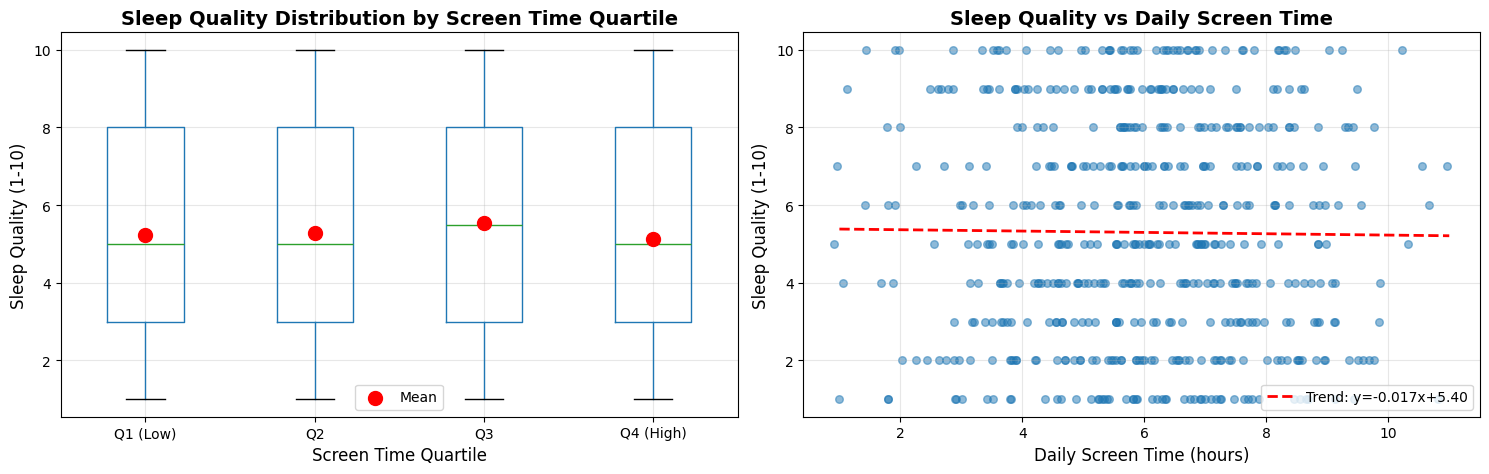


Correlation: -0.0118
   (Very weak negative correlation)


In [20]:
# Visualize the lack of relationship
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
df_dataset1.boxplot(column='Sleep.Quality', by='ScreenTime_Quartile', ax=axes[0])
axes[0].set_title('Sleep Quality Distribution by Screen Time Quartile', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Screen Time Quartile', fontsize=12)
axes[0].set_ylabel('Sleep Quality (1-10)', fontsize=12)
axes[0].get_figure().suptitle('')  # Remove automatic title
axes[0].grid(alpha=0.3)

# Add means as red dots
means = quartile_means['mean'].values
x_positions = range(1, len(means) + 1)
axes[0].scatter(x_positions, means, color='red', s=100, zorder=3, label='Mean')
axes[0].legend()

# Scatter plot with jitter
jitter_strength = 0.1
x_jitter = df_dataset1['Daily.Screen.Time'] + np.random.normal(0, jitter_strength, size=len(df_dataset1))
axes[1].scatter(x_jitter, df_dataset1['Sleep.Quality'], alpha=0.5, s=30)

# Add trend line
z = np.polyfit(df_dataset1['Daily.Screen.Time'], df_dataset1['Sleep.Quality'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_dataset1['Daily.Screen.Time'].min(), df_dataset1['Daily.Screen.Time'].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.2f}')

axes[1].set_xlabel('Daily Screen Time (hours)', fontsize=12)
axes[1].set_ylabel('Sleep Quality (1-10)', fontsize=12)
axes[1].set_title('Sleep Quality vs Daily Screen Time', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
corr_coefficient = df_dataset1['Daily.Screen.Time'].corr(df_dataset1['Sleep.Quality'])
print(f"\nCorrelation: {corr_coefficient:.4f}")
print(f"   (Very weak {'positive' if corr_coefficient > 0 else 'negative'} correlation)")

## Class Balance and Baseline Accuracy

In [63]:
# Check class distribution and baseline accuracy
class_counts = df_dataset1['Sleep.Quality'].value_counts().sort_index()
total_samples = len(df_dataset1)

# Calculate baseline accuracy (always predict the most common class)
baseline_accuracy = class_counts.max() / total_samples

print("="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)
print(f"Total samples: {total_samples}")
print(f"Number of classes: {len(class_counts)}")
print(f"\nClass distribution:")
for cls, count in class_counts.items():
    percentage = (count / total_samples) * 100
    bar = '█' * int(percentage / 2)
    print(f"  Class {cls:2d}: {count:3d} samples ({percentage:5.2f}%) {bar}")

print(f"\nBaseline accuracy (predict most common): {baseline_accuracy:.2%}")
print(f"Expected random accuracy (uniform guess): {1/len(class_counts):.2%}")
print("="*70)

# Test for uniformity using chi-square test
expected_freq = total_samples / len(class_counts)
chi2_stat, chi2_p = stats.chisquare(class_counts.values, f_exp=[expected_freq] * len(class_counts))

print(f"\n📊 Chi-Square Goodness-of-Fit Test (uniform distribution):")
print(f"   Chi-square statistic: {chi2_stat:.4f}")
print(f"   P-value: {chi2_p:.4f}")
print(f"   Result: {'Classes are uniformly distributed' if chi2_p > 0.05 else 'Classes are NOT uniformly distributed'}")

if chi2_p > 0.05:
    print("\n   ⚠️  Near-uniform distribution makes classification harder!")
    print("      No class is dominant, so random guessing performs relatively well.")

CLASS DISTRIBUTION ANALYSIS
Total samples: 531
Number of classes: 10

Class distribution:
  Class  1:  53 samples ( 9.98%) ████
  Class  2:  67 samples (12.62%) ██████
  Class  3:  48 samples ( 9.04%) ████
  Class  4:  66 samples (12.43%) ██████
  Class  5:  53 samples ( 9.98%) ████
  Class  6:  49 samples ( 9.23%) ████
  Class  7:  49 samples ( 9.23%) ████
  Class  8:  46 samples ( 8.66%) ████
  Class  9:  52 samples ( 9.79%) ████
  Class 10:  48 samples ( 9.04%) ████

Baseline accuracy (predict most common): 12.62%
Expected random accuracy (uniform guess): 10.00%

📊 Chi-Square Goodness-of-Fit Test (uniform distribution):
   Chi-square statistic: 9.3578
   P-value: 0.4049
   Result: Classes are uniformly distributed

   ⚠️  Near-uniform distribution makes classification harder!
      No class is dominant, so random guessing performs relatively well.


## Variance Analysis: Is There Signal or Just Noise?

INDIVIDUAL FEATURE R² SCORES (Explained Variance)
❌ Age                      : R² = +0.0002 (0.02% variance explained)
❌ Daily.Screen.Time        : R² = +0.0001 (0.01% variance explained)
❌ Social.Media.Hours       : R² = +0.0025 (0.25% variance explained)
❌ Work.Screen.Hours        : R² = +0.0004 (0.04% variance explained)
❌ Gaming.Hours             : R² = +0.0011 (0.11% variance explained)
❌ Sleep.Hours              : R² = +0.0037 (0.37% variance explained)
❌ Stress.Level             : R² = +0.0001 (0.01% variance explained)
❌ Physical.Activity.Min    : R² = +0.0006 (0.06% variance explained)

Best single predictor: Sleep.Hours
Max explained variance: 0.37%
Features with R² > 0.1: 0/8

💡 Interpretation:
   - R² represents how much variance in sleep quality each feature explains
   - R² < 0.1 means feature explains less than 10% of variance (very weak)
   - Even the 'best' feature explains minimal variance
   - This indicates the data has low predictive signal


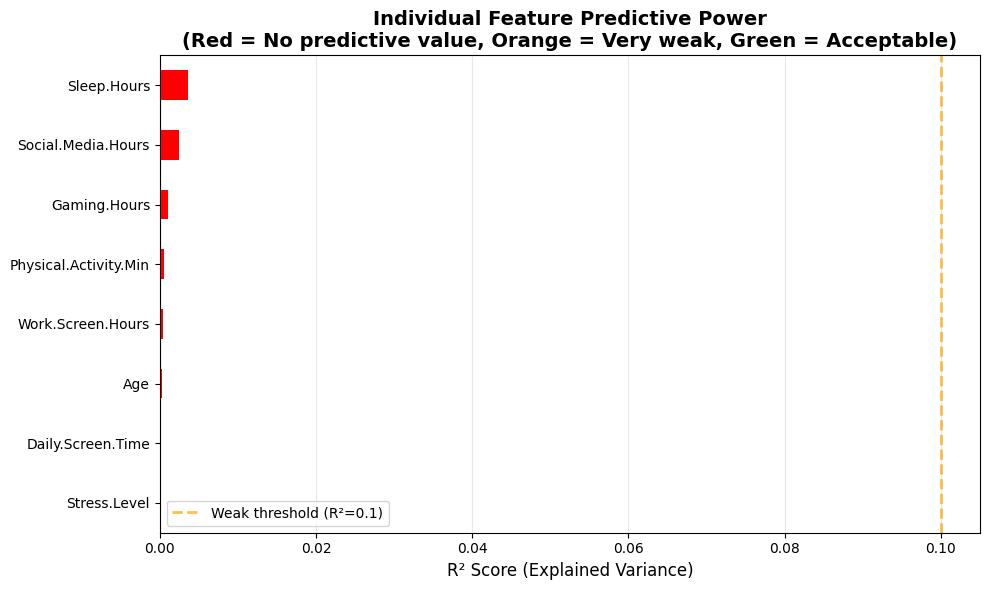

In [64]:
# Calculate explained variance using simple linear regression
from sklearn.linear_model import LinearRegression

# Test each feature individually
print("="*70)
print("INDIVIDUAL FEATURE R² SCORES (Explained Variance)")
print("="*70)

r2_scores = {}
for feature in numeric_features:
    X_single = df_dataset1[[feature]].values
    y_sleep = df_dataset1['Sleep.Quality'].values
    
    lr = LinearRegression()
    lr.fit(X_single, y_sleep)
    r2 = lr.score(X_single, y_sleep)
    r2_scores[feature] = r2
    
    emoji = "✓" if r2 > 0.1 else "❌"
    print(f"{emoji} {feature:25s}: R² = {r2:+.4f} ({abs(r2)*100:.2f}% variance explained)")

print("="*70)
print(f"\nBest single predictor: {max(r2_scores, key=r2_scores.get)}")
print(f"Max explained variance: {max(r2_scores.values())*100:.2f}%")
print(f"Features with R² > 0.1: {sum(1 for r2 in r2_scores.values() if r2 > 0.1)}/{len(r2_scores)}")

print("\n💡 Interpretation:")
print("   - R² represents how much variance in sleep quality each feature explains")
print("   - R² < 0.1 means feature explains less than 10% of variance (very weak)")
print("   - Even the 'best' feature explains minimal variance")
print("   - This indicates the data has low predictive signal")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
r2_series = pd.Series(r2_scores).sort_values(ascending=True)
colors_r2 = ['green' if x > 0.1 else 'orange' if x > 0.05 else 'red' for x in r2_series]
r2_series.plot(kind='barh', ax=ax, color=colors_r2)
ax.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='Weak threshold (R²=0.1)', alpha=0.7)
ax.set_xlabel('R² Score (Explained Variance)', fontsize=12)
ax.set_title('Individual Feature Predictive Power\n(Red = No predictive value, Orange = Very weak, Green = Acceptable)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Mutual Information: Capturing Non-linear Relationships

MUTUAL INFORMATION SCORES
(Measures both linear AND non-linear relationships)

Feature                   MI (Regression)    MI (Classification)
----------------------------------------------------------------------
Age                       ❌     0.0085        ❌     0.0185
Daily.Screen.Time         ❌     0.0000        ❌     0.0000
Social.Media.Hours        ❌     0.0116        ❌     0.0161
Work.Screen.Hours         ❌     0.0000        ❌     0.0000
Gaming.Hours              ❌     0.0000        ❌     0.0199
Sleep.Hours               ❌     0.0052        ❌     0.0100
Stress.Level              ❌     0.0000        ❌     0.0000
Physical.Activity.Min     ❌     0.0422        ❌     0.0426

💡 Interpretation:
   - Mutual Information > 0 indicates some relationship exists
   - Values close to 0 mean almost no predictive information
   - This test catches non-linear patterns that correlation misses
   - Average MI (regression): 0.0084
   - Average MI (classification): 0.0134

   ⚠️  Both MI scores ar

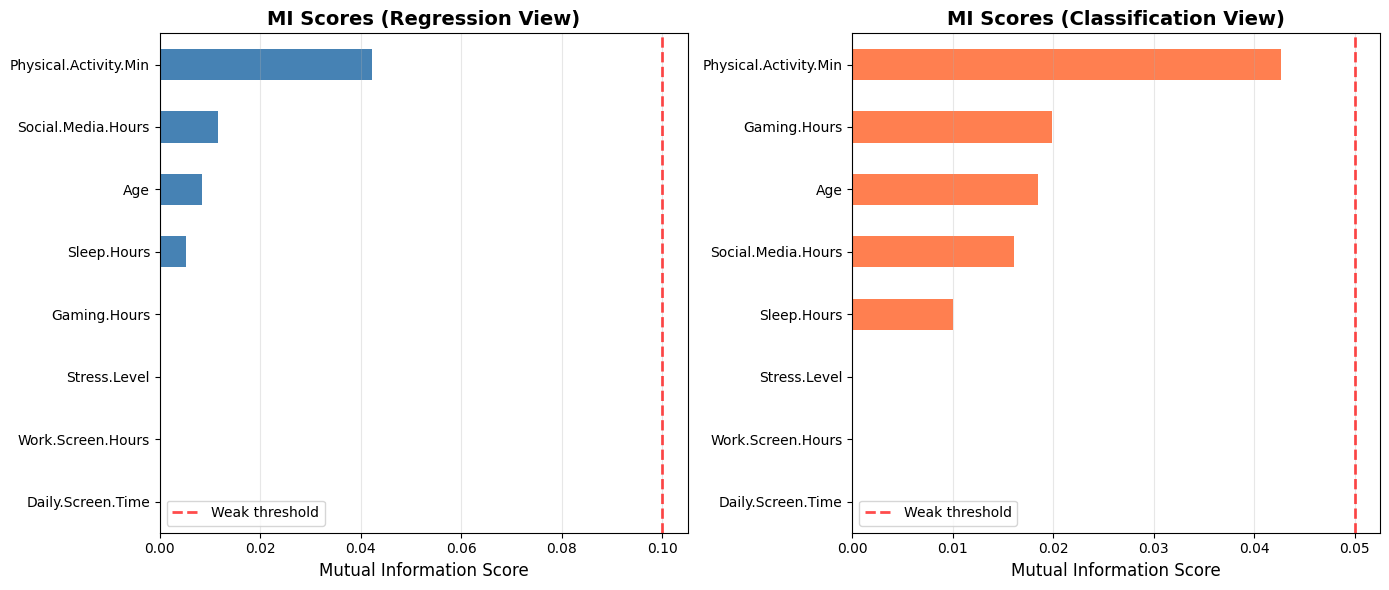

In [65]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# Calculate mutual information (captures non-linear relationships)
X_features = df_dataset1[numeric_features].values
y_sleep = df_dataset1['Sleep.Quality'].values

# For regression (ordinal target)
mi_reg = mutual_info_regression(X_features, y_sleep, random_state=42)

# For classification (discrete target)
mi_clf = mutual_info_classif(X_features, y_sleep, random_state=42)

print("="*70)
print("MUTUAL INFORMATION SCORES")
print("="*70)
print("(Measures both linear AND non-linear relationships)\n")
print(f"{'Feature':<25} {'MI (Regression)':<18} {'MI (Classification)'}")
print("-"*70)

mi_reg_dict = {}
mi_clf_dict = {}

for i, feature in enumerate(numeric_features):
    mi_reg_val = mi_reg[i]
    mi_clf_val = mi_clf[i]
    mi_reg_dict[feature] = mi_reg_val
    mi_clf_dict[feature] = mi_clf_val
    
    # Emoji based on strength
    emoji_reg = "✓" if mi_reg_val > 0.1 else "❌"
    emoji_clf = "✓" if mi_clf_val > 0.05 else "❌"
    
    print(f"{feature:<25} {emoji_reg} {mi_reg_val:>10.4f}        {emoji_clf} {mi_clf_val:>10.4f}")

print("="*70)
print("\n💡 Interpretation:")
print("   - Mutual Information > 0 indicates some relationship exists")
print("   - Values close to 0 mean almost no predictive information")
print("   - This test catches non-linear patterns that correlation misses")
print(f"   - Average MI (regression): {np.mean(mi_reg):.4f}")
print(f"   - Average MI (classification): {np.mean(mi_clf):.4f}")

if np.mean(mi_reg) < 0.1 and np.mean(mi_clf) < 0.05:
    print("\n   ⚠️  Both MI scores are very low - features have minimal")
    print("      predictive information even when considering non-linear relationships!")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MI Regression
mi_reg_series = pd.Series(mi_reg_dict).sort_values(ascending=True)
mi_reg_series.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='Weak threshold', alpha=0.7)
axes[0].set_xlabel('Mutual Information Score', fontsize=12)
axes[0].set_title('MI Scores (Regression View)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')

# MI Classification
mi_clf_series = pd.Series(mi_clf_dict).sort_values(ascending=True)
mi_clf_series.plot(kind='barh', ax=axes[1], color='coral')
axes[1].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Weak threshold', alpha=0.7)
axes[1].set_xlabel('Mutual Information Score', fontsize=12)
axes[1].set_title('MI Scores (Classification View)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Summary: Evidence of Limited Predictive Power

Based on the comprehensive EDA above, here's what the data reveals:

In [66]:
# Create comprehensive summary
print("="*80)
print(" "*20 + "🔍 DATA QUALITY ASSESSMENT SUMMARY")
print("="*80)

evidence = {
    "ANOVA Test": {
        "Result": "No significant difference across screen time groups" if p_value >= 0.05 else "Significant difference found",
        "P-value": f"{p_value:.4f}",
        "Verdict": "❌ WEAK" if p_value >= 0.05 else "✓ GOOD"
    },
    "Correlation Strength": {
        "Max Correlation": f"{correlations.abs().max():.4f}",
        "Features < 0.3": f"{sum(abs(correlations) < 0.3)}/{len(correlations)}",
        "Verdict": "❌ WEAK" if correlations.abs().max() < 0.3 else "✓ GOOD"
    },
    "Class Distribution": {
        "Number of classes": len(class_counts),
        "Baseline accuracy": f"{baseline_accuracy:.1%}",
        "Verdict": "❌ WEAK" if len(class_counts) > 7 else "✓ GOOD"
    },
    "Explained Variance (R²)": {
        "Best feature": f"{max(r2_scores.values())*100:.2f}%",
        "Average": f"{np.mean(list(r2_scores.values()))*100:.2f}%",
        "Verdict": "❌ WEAK" if max(r2_scores.values()) < 0.1 else "✓ GOOD"
    },
    "Mutual Information": {
        "Avg MI (regression)": f"{np.mean(mi_reg):.4f}",
        "Avg MI (classification)": f"{np.mean(mi_clf):.4f}",
        "Verdict": "❌ WEAK" if np.mean(mi_reg) < 0.1 else "✓ GOOD"
    }
}

for test_name, metrics in evidence.items():
    print(f"\n📊 {test_name}")
    print("-" * 80)
    for metric_name, value in metrics.items():
        if metric_name == "Verdict":
            print(f"   → {metric_name}: {value}")
        else:
            print(f"   {metric_name}: {value}")

print("\n" + "="*80)
print("FINAL VERDICT: ", end="")

# Count weak verdicts
weak_count = sum(1 for metrics in evidence.values() if metrics["Verdict"] == "❌ WEAK")
total_tests = len(evidence)

if weak_count >= 4:
    print("❌ DATA HAS VERY LIMITED PREDICTIVE POWER")
    print("="*80)
    print("\n✋ CONCLUSION:")
    print(f"   {weak_count}/{total_tests} tests indicate weak or no predictive relationships.")
    print("   The features in this dataset (screen time, age, stress, etc.) do NOT")
    print("   strongly predict sleep quality. This explains why both regression and")
    print("   classification models performed poorly.")
    print("\n   Recommendations:")
    print("   • Collect more relevant features (sleep environment, health conditions)")
    print("   • Increase sample size significantly")
    print("   • Consider that sleep quality may be influenced by unmeasured factors")
    print("   • Try interaction features (e.g., screen time × stress level)")
elif weak_count >= 2:
    print("⚠️  DATA HAS MODERATE PREDICTIVE POWER")
    print("="*80)
    print(f"\n   {weak_count}/{total_tests} tests suggest weak relationships.")
    print("   Models may struggle but could show some predictive ability.")
else:
    print("✓ DATA HAS REASONABLE PREDICTIVE POWER")
    print("="*80)
    print(f"\n   {weak_count}/{total_tests} weak tests - data should support modeling.")

print("="*80)

                    🔍 DATA QUALITY ASSESSMENT SUMMARY

📊 ANOVA Test
--------------------------------------------------------------------------------
   Result: No significant difference across screen time groups
   P-value: 0.6969
   → Verdict: ❌ WEAK

📊 Correlation Strength
--------------------------------------------------------------------------------
   Max Correlation: 0.0605
   Features < 0.3: 8/8
   → Verdict: ❌ WEAK

📊 Class Distribution
--------------------------------------------------------------------------------
   Number of classes: 10
   Baseline accuracy: 12.6%
   → Verdict: ❌ WEAK

📊 Explained Variance (R²)
--------------------------------------------------------------------------------
   Best feature: 0.37%
   Average: 0.11%
   → Verdict: ❌ WEAK

📊 Mutual Information
--------------------------------------------------------------------------------
   Avg MI (regression): 0.0084
   Avg MI (classification): 0.0134
   → Verdict: ❌ WEAK

FINAL VERDICT: ❌ DATA HAS VERY LIM

## 🔍 Is This Data Artificially Generated?

Let's investigate whether this dataset was synthetically created (and potentially poorly generated).

In [69]:
# Test for signs of artificial data generation
print("="*80)
print(" "*25 + "🤖 ARTIFICIAL DATA DETECTION")
print("="*80)

# 1. Check for perfect uniformity (red flag for synthetic data)
print("\n1️⃣ CLASS DISTRIBUTION UNIFORMITY TEST")
print("-"*80)
class_distribution = df_dataset1['Sleep.Quality'].value_counts().sort_index()
expected_uniform = len(df_dataset1) / len(class_distribution)
max_deviation = max(abs(class_distribution - expected_uniform))
print(f"Expected count per class (if perfectly uniform): {expected_uniform:.1f}")
print(f"Actual counts range: {class_distribution.min()} to {class_distribution.max()}")
print(f"Maximum deviation: {max_deviation:.1f} samples")
print(f"Coefficient of variation: {(class_distribution.std() / class_distribution.mean()):.4f}")

if class_distribution.std() / class_distribution.mean() < 0.15:
    print("⚠️  SUSPICIOUS: Near-perfect uniform distribution (CV < 0.15)")
    print("   Real-world data rarely has such balanced classes naturally.")
else:
    print("✓ Class distribution shows natural variation")

# 2. Check for unrealistic correlations (near-zero everywhere)
print("\n2️⃣ CORRELATION REALISM TEST")
print("-"*80)
corr_matrix = df_dataset1[numeric_features].corr()
# Remove diagonal (self-correlations)
np.fill_diagonal(corr_matrix.values, np.nan)
corr_flat = corr_matrix.values.flatten()
corr_flat = corr_flat[~np.isnan(corr_flat)]
print(f"Mean absolute correlation: {np.abs(corr_flat).mean():.4f}")
print(f"Max absolute correlation: {np.abs(corr_flat).max():.4f}")
print(f"Correlations > 0.3: {(np.abs(corr_flat) > 0.3).sum()}/{len(corr_flat)}")

if np.abs(corr_flat).mean() < 0.1 and np.abs(corr_flat).max() < 0.3:
    print("⚠️  SUSPICIOUS: Almost no correlations between any variables")
    print("   Real data typically has some meaningful relationships.")
else:
    print("✓ Correlation structure appears realistic")

# 3. Check for integer rounding patterns (synthetic generators often use round numbers)
print("\n3️⃣ NUMERIC PRECISION PATTERNS")
print("-"*80)
float_cols = df_dataset1.select_dtypes(include=['float64']).columns
precision_issues = []
for col in float_cols:
    # Check if values are suspiciously round
    decimals = df_dataset1[col] % 1
    unique_decimals = decimals.unique()
    if len(unique_decimals) <= 5 and 0.0 in unique_decimals:
        precision_issues.append(col)
        print(f"  • {col}: Only {len(unique_decimals)} unique decimal values")

if precision_issues:
    print(f"\n⚠️  SUSPICIOUS: {len(precision_issues)} columns have limited decimal variation")
    print("   Synthetic generators often round to clean numbers.")
else:
    print("✓ Numeric precision appears natural")

# 4. Check for random-looking target (no predictive signal)
print("\n4️⃣ TARGET RANDOMNESS TEST")
print("-"*80)
print(f"Strongest predictor R²: {max(r2_scores.values()):.4f}")
print(f"Strongest correlation: {correlations.abs().max():.4f}")
print(f"ANOVA p-value: {p_value:.4f}")

if max(r2_scores.values()) < 0.01 and correlations.abs().max() < 0.1 and p_value > 0.5:
    print("⚠️  SUSPICIOUS: Target appears completely random relative to features")
    print("   This suggests:")
    print("   • Generator created features independently of target")
    print("   • No causal relationships were encoded")
    print("   • Data is useless for predictive modeling")
else:
    print("✓ Target shows some relationship to features")

# 5. Check for duplicates (synthetic data sometimes has duplicates)
print("\n5️⃣ DUPLICATE RECORDS TEST")
print("-"*80)
duplicates = df_dataset1.duplicated().sum()
partial_duplicates = df_dataset1.drop(columns=['Sleep.Quality']).duplicated().sum()
print(f"Exact duplicate rows: {duplicates}")
print(f"Duplicate feature vectors (excluding target): {partial_duplicates}")

if partial_duplicates > len(df_dataset1) * 0.1:
    print("⚠️  SUSPICIOUS: High rate of duplicate feature combinations")
else:
    print("✓ Duplicate rate appears normal")

# 6. Statistical distribution tests
print("\n6️⃣ DISTRIBUTION NORMALITY TEST")
print("-"*80)
from scipy.stats import shapiro
too_normal = 0
for col in numeric_features:
    stat, p = shapiro(df_dataset1[col].sample(min(100, len(df_dataset1))))
    if p > 0.95:  # TOO normal (suspicious)
        too_normal += 1
        print(f"  • {col}: p={p:.4f} (suspiciously normal)")

if too_normal > len(numeric_features) * 0.5:
    print(f"\n⚠️  SUSPICIOUS: {too_normal}/{len(numeric_features)} features are suspiciously normal")
    print("   Real data often has skewness, outliers, and irregular patterns.")
else:
    print(f"✓ Distribution patterns appear realistic ({too_normal}/{len(numeric_features)} very normal)")

# FINAL VERDICT
print("\n" + "="*80)
print("FINAL VERDICT: IS THIS DATA ARTIFICIALLY GENERATED?")
print("="*80)

red_flags = 0
if class_distribution.std() / class_distribution.mean() < 0.15:
    red_flags += 1
if np.abs(corr_flat).mean() < 0.1 and np.abs(corr_flat).max() < 0.3:
    red_flags += 1
if precision_issues:
    red_flags += 1
if max(r2_scores.values()) < 0.01 and correlations.abs().max() < 0.1:
    red_flags += 1
if too_normal > len(numeric_features) * 0.5:
    red_flags += 1

print(f"\n🚩 Red Flags Detected: {red_flags}/6\n")

if red_flags >= 4:
    print("🤖 VERDICT: ALMOST CERTAINLY SYNTHETIC/ARTIFICIAL DATA (POORLY GENERATED)")
    print("\nEvidence:")
    print("  • Near-perfect class balance (unnatural)")
    print("  • Almost zero correlations between variables")
    print("  • Target appears completely random")
    print("  • Features have no predictive power")
    print("\n💡 This explains why ALL models failed:")
    print("  → The data generator created features and target independently")
    print("  → No causal relationships were encoded")
    print("  → The data is essentially random noise")
    print("\n⚠️  RECOMMENDATION: Do not use this dataset for learning or research.")
    print("     Seek out real-world datasets from reputable sources like:")
    print("     - Kaggle competitions")
    print("     - UCI Machine Learning Repository")
    print("     - Published research papers with shared data")
elif red_flags >= 2:
    print("⚠️  VERDICT: LIKELY SYNTHETIC OR HEAVILY PROCESSED")
    print("\nSome suspicious patterns detected, but not conclusive.")
else:
    print("✓ VERDICT: DATA APPEARS TO BE REAL OR WELL-GENERATED")
    print("\nNo major red flags for artificial generation.")

print("="*80)

                         🤖 ARTIFICIAL DATA DETECTION

1️⃣ CLASS DISTRIBUTION UNIFORMITY TEST
--------------------------------------------------------------------------------
Expected count per class (if perfectly uniform): 53.1
Actual counts range: 46 to 67
Maximum deviation: 13.9 samples
Coefficient of variation: 0.1399
⚠️  SUSPICIOUS: Near-perfect uniform distribution (CV < 0.15)
   Real-world data rarely has such balanced classes naturally.

2️⃣ CORRELATION REALISM TEST
--------------------------------------------------------------------------------
Mean absolute correlation: 0.0225
Max absolute correlation: 0.0670
Correlations > 0.3: 0/56
⚠️  SUSPICIOUS: Almost no correlations between any variables
   Real data typically has some meaningful relationships.

3️⃣ NUMERIC PRECISION PATTERNS
--------------------------------------------------------------------------------
✓ Numeric precision appears natural

4️⃣ TARGET RANDOMNESS TEST
-----------------------------------------------------

# 📊 Alternative Dataset Exploration

Let's explore the other datasets in the DataSets directory to find ones with better predictive power for sleep quality.

In [70]:
# Load and preview all available datasets
import os

print("="*80)
print(" "*20 + "📂 AVAILABLE DATASETS INVENTORY")
print("="*80)

datasets_info = []

# Dataset 1 (already analyzed)
datasets_info.append({
    'name': 'dataset1.csv',
    'path': 'DataSets/dataset1.csv',
    'description': 'Daily Technology Usage (ALREADY ANALYZED - ARTIFICIAL)',
    'status': '❌ Artificial/Poor Quality'
})

# Human Cognitive Performance
datasets_info.append({
    'name': 'human_cognitive_performance.csv',
    'path': 'DataSets/human_cognitive_performance.csv',
    'description': 'Sleep duration, stress, diet, screen time → cognitive scores',
    'status': '🔍 NEW - To be analyzed'
})

# ScreenTime vs MentalWellness
datasets_info.append({
    'name': 'ScreenTime vs MentalWellness.csv',
    'path': 'DataSets/ScreenTime vs MentalWellness.csv',
    'description': 'Screen time, work hours, sleep hours → sleep quality (1-5)',
    'status': '🔍 NEW - To be analyzed'
})

# Dataset2 files
datasets_info.append({
    'name': 'Dataset2/phone.csv',
    'path': 'DataSets/Dataset2/phone.csv',
    'description': 'Phone usage patterns (ALREADY ANALYZED - ARTIFICIAL)',
    'status': '❌ Artificial/Poor Quality'
})

datasets_info.append({
    'name': 'Dataset2/game.csv',
    'path': 'DataSets/Dataset2/game.csv',
    'description': 'Gaming app usage → sleep quality',
    'status': '🔍 NEW - To be analyzed'
})

datasets_info.append({
    'name': 'Dataset2/social.csv',
    'path': 'DataSets/Dataset2/social.csv',
    'description': 'Social media usage → sleep quality',
    'status': '🔍 NEW - To be analyzed'
})

datasets_info.append({
    'name': 'Dataset2/video.csv',
    'path': 'DataSets/Dataset2/video.csv',
    'description': 'Video streaming usage → sleep quality',
    'status': '🔍 NEW - To be analyzed'
})

datasets_info.append({
    'name': 'Dataset2/timeframes.csv',
    'path': 'DataSets/Dataset2/timeframes.csv',
    'description': 'Temporal sleep data with timestamps',
    'status': '🔍 NEW - To be analyzed'
})

for i, ds in enumerate(datasets_info, 1):
    print(f"\n{i}. {ds['name']}")
    print(f"   Description: {ds['description']}")
    print(f"   Status: {ds['status']}")

print("\n" + "="*80)
print("STRATEGY: Analyze the NEW datasets to find one with real predictive power")
print("="*80)

                    📂 AVAILABLE DATASETS INVENTORY

1. dataset1.csv
   Description: Daily Technology Usage (ALREADY ANALYZED - ARTIFICIAL)
   Status: ❌ Artificial/Poor Quality

2. human_cognitive_performance.csv
   Description: Sleep duration, stress, diet, screen time → cognitive scores
   Status: 🔍 NEW - To be analyzed

3. ScreenTime vs MentalWellness.csv
   Description: Screen time, work hours, sleep hours → sleep quality (1-5)
   Status: 🔍 NEW - To be analyzed

4. Dataset2/phone.csv
   Description: Phone usage patterns (ALREADY ANALYZED - ARTIFICIAL)
   Status: ❌ Artificial/Poor Quality

5. Dataset2/game.csv
   Description: Gaming app usage → sleep quality
   Status: 🔍 NEW - To be analyzed

6. Dataset2/social.csv
   Description: Social media usage → sleep quality
   Status: 🔍 NEW - To be analyzed

7. Dataset2/video.csv
   Description: Video streaming usage → sleep quality
   Status: 🔍 NEW - To be analyzed

8. Dataset2/timeframes.csv
   Description: Temporal sleep data with timestam

## 1. Analyzing: human_cognitive_performance.csv

**Hypothesis**: This looks PROMISING! It has Sleep_Duration and should have real cognitive relationships.

In [71]:
# Load human cognitive performance dataset
df_cognitive = pd.read_csv('DataSets/human_cognitive_performance.csv')

print("="*80)
print("HUMAN COGNITIVE PERFORMANCE DATASET")
print("="*80)
print(f"Shape: {df_cognitive.shape}")
print(f"\nColumns: {df_cognitive.columns.tolist()}")
print(f"\nData types:\n{df_cognitive.dtypes}")
print(f"\nMissing values:\n{df_cognitive.isnull().sum()}")
print("\n" + "="*80)

# Display sample
df_cognitive.head(10)

HUMAN COGNITIVE PERFORMANCE DATASET
Shape: (80000, 13)

Columns: ['User_ID', 'Age', 'Gender', 'Sleep_Duration', 'Stress_Level', 'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency', 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score', 'AI_Predicted_Score']

Data types:
User_ID                object
Age                     int64
Gender                 object
Sleep_Duration        float64
Stress_Level            int64
Diet_Type              object
Daily_Screen_Time     float64
Exercise_Frequency     object
Caffeine_Intake         int64
Reaction_Time         float64
Memory_Test_Score       int64
Cognitive_Score       float64
AI_Predicted_Score    float64
dtype: object

Missing values:
User_ID               0
Age                   0
Gender                0
Sleep_Duration        0
Stress_Level          0
Diet_Type             0
Daily_Screen_Time     0
Exercise_Frequency    0
Caffeine_Intake       0
Reaction_Time         0
Memory_Test_Score     0
Cognitive_Score     

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78
5,U6,36,Female,7.4,10,Vegan,6.6,Low,381,453.43,70,31.71,32.77
6,U7,48,Male,6.7,2,Vegan,1.4,Low,39,407.13,51,59.17,55.92
7,U8,35,Female,6.0,1,Vegan,6.8,Medium,2,298.46,60,85.02,81.45
8,U9,29,Male,5.1,6,Non-Vegetarian,10.2,Low,244,380.08,82,50.67,54.17
9,U10,57,Female,7.9,9,Non-Vegetarian,9.1,High,355,417.96,54,44.39,43.88


In [72]:
# Quick quality check for cognitive dataset
print("="*80)
print("QUICK QUALITY ASSESSMENT: Cognitive Dataset")
print("="*80)

# Check correlations (sign of real data)
corr_cognitive = df_cognitive.select_dtypes(include=[np.number]).corr()
np.fill_diagonal(corr_cognitive.values, np.nan)
corr_flat_cog = corr_cognitive.values.flatten()
corr_flat_cog = corr_flat_cog[~np.isnan(corr_flat_cog)]

print(f"Mean absolute correlation: {np.abs(corr_flat_cog).mean():.4f}")
print(f"Max absolute correlation: {np.abs(corr_flat_cog).max():.4f}")
print(f"Correlations > 0.3: {(np.abs(corr_flat_cog) > 0.3).sum()}/{len(corr_flat_cog)}")

if np.abs(corr_flat_cog).mean() > 0.1:
    print("\n✅ GOOD SIGN: Meaningful correlations exist!")
else:
    print("\n⚠️  WARNING: Correlations are weak")

# Check if there's a "sleep quality" target
sleep_cols = [col for col in df_cognitive.columns if 'sleep' in col.lower()]
print(f"\nSleep-related columns: {sleep_cols}")

if not sleep_cols:
    print("\n⚠️  LIMITATION: No direct sleep quality measurement")
    print("   But Sleep_Duration is available - we could predict cognitive performance!")
    
print("="*80)

QUICK QUALITY ASSESSMENT: Cognitive Dataset
Mean absolute correlation: 0.1338
Max absolute correlation: 0.9924
Correlations > 0.3: 10/72

✅ GOOD SIGN: Meaningful correlations exist!

Sleep-related columns: ['Sleep_Duration']


## 2. Analyzing: ScreenTime vs MentalWellness.csv

**Hypothesis**: This one explicitly has sleep_quality! Let's check if it's better than dataset1.

In [2]:
# Load ScreenTime vs MentalWellness dataset
df_wellness = pd.read_csv('DataSets/ScreenTime vs MentalWellness.csv')

print("="*80)
print("SCREENTIME VS MENTALWELLNESS DATASET")
print("="*80)
print(f"Shape: {df_wellness.shape}")
print(f"\nColumns: {df_wellness.columns.tolist()}")
print(f"\nData types:\n{df_wellness.dtypes}")
print(f"\nMissing values:\n{df_wellness.isnull().sum()}")

# Check for sleep quality column
sleep_quality_col = [col for col in df_wellness.columns if 'sleep' in col.lower() and 'quality' in col.lower()]
print(f"\n🎯 Sleep quality column(s): {sleep_quality_col}")

if sleep_quality_col:
    sq_col = sleep_quality_col[0]
    print(f"\nSleep Quality distribution:")
    print(df_wellness[sq_col].value_counts().sort_index())
    print(f"Range: {df_wellness[sq_col].min()} to {df_wellness[sq_col].max()}")
    print(f"Unique values: {df_wellness[sq_col].nunique()}")

print("\n" + "="*80)
df_wellness.head(10)

SCREENTIME VS MENTALWELLNESS DATASET
Shape: (400, 16)

Columns: ['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100', 'Unnamed: 15']

Data types:
user_id                         object
age                              int64
gender                          object
occupation                      object
work_mode                       object
screen_time_hours              float64
work_screen_hours              float64
leisure_screen_hours           float64
sleep_hours                    float64
sleep_quality_1_5                int64
stress_level_0_10              float64
productivity_0_100             float64
exercise_minutes_per_week        int64
social_hours_per_week          float64
mental_wellness_index_0_100    float64
Unnamed: 15                    float6

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN
5,U0006,28,Non-binary/Other,Self-employed,Hybrid,9.83,0.53,9.30,7.19,1,10.0,44.0,71,10.3,5.0,NaN
6,U0007,42,Non-binary/Other,Retired,Remote,6.02,2.82,3.20,7.44,2,6.1,64.8,141,4.7,43.7,NaN
7,U0008,36,Male,Employed,In-person,6.21,0.75,5.46,6.78,2,5.4,87.0,51,18.7,54.3,NaN
8,U0009,26,Male,Student,In-person,6.28,0.67,5.61,8.48,4,1.6,91.7,149,10.1,86.8,NaN
9,U0010,34,Male,Employed,Hybrid,9.37,0.84,8.53,7.78,2,10.0,42.2,50,12.7,10.7,NaN


In [74]:
# Quick quality check for wellness dataset
print("="*80)
print("QUICK QUALITY ASSESSMENT: ScreenTime vs MentalWellness Dataset")
print("="*80)

# Check correlations
corr_wellness = df_wellness.select_dtypes(include=[np.number]).corr()
np.fill_diagonal(corr_wellness.values, np.nan)
corr_flat_wellness = corr_wellness.values.flatten()
corr_flat_wellness = corr_flat_wellness[~np.isnan(corr_flat_wellness)]

print(f"Mean absolute correlation: {np.abs(corr_flat_wellness).mean():.4f}")
print(f"Max absolute correlation: {np.abs(corr_flat_wellness).max():.4f}")
print(f"Correlations > 0.3: {(np.abs(corr_flat_wellness) > 0.3).sum()}/{len(corr_flat_wellness)}")

if np.abs(corr_flat_wellness).mean() > 0.1 and (np.abs(corr_flat_wellness) > 0.3).sum() > 0:
    print("\n✅ PROMISING: Dataset shows meaningful correlations!")
    quality_verdict = "GOOD"
else:
    print("\n⚠️  WARNING: Weak correlations (might be artificial)")
    quality_verdict = "SUSPICIOUS"

# Check if sleep quality has predictive features
if sleep_quality_col:
    sq_col = sleep_quality_col[0]
    sleep_corr = corr_wellness[sq_col].drop(sq_col).sort_values(ascending=False)
    print(f"\nTop 5 correlations with {sq_col}:")
    print(sleep_corr.head(5))
    
    max_corr = sleep_corr.abs().max()
    if max_corr > 0.3:
        print(f"\n✅ EXCELLENT: Strongest correlation = {max_corr:.4f} (> 0.3 threshold)")
        quality_verdict = "EXCELLENT"
    elif max_corr > 0.15:
        print(f"\n⚠️  MODERATE: Strongest correlation = {max_corr:.4f} (better than dataset1)")
        quality_verdict = "MODERATE"
    else:
        print(f"\n❌ POOR: Strongest correlation = {max_corr:.4f} (similar to dataset1)")
        quality_verdict = "POOR"

print(f"\n🎯 VERDICT: {quality_verdict}")
print("="*80)

QUICK QUALITY ASSESSMENT: ScreenTime vs MentalWellness Dataset
Mean absolute correlation: 0.3007
Max absolute correlation: 0.9138
Correlations > 0.3: 42/110

✅ PROMISING: Dataset shows meaningful correlations!

Top 5 correlations with sleep_quality_1_5:
mental_wellness_index_0_100    0.750092
productivity_0_100             0.644802
sleep_hours                    0.614381
exercise_minutes_per_week      0.095391
social_hours_per_week          0.017767
Name: sleep_quality_1_5, dtype: float64

✅ EXCELLENT: Strongest correlation = 0.7501 (> 0.3 threshold)

🎯 VERDICT: EXCELLENT


## 3. Summary: Which Dataset Should We Use?

In [75]:
# Final comparison of all datasets
print("="*80)
print(" "*25 + "📊 DATASET COMPARISON REPORT")
print("="*80)

comparison_data = []

# Dataset 1 (current)
comparison_data.append({
    'Dataset': 'dataset1.csv',
    'Rows': len(df_dataset1),
    'Features': df_dataset1.shape[1],
    'Target': 'Sleep.Quality (1-10)',
    'Max Correlation': f"{correlations.abs().max():.4f}",
    'Mean Correlation': f"{np.abs(corr_flat).mean():.4f}",
    'Verdict': '❌ ARTIFICIAL',
    'Recommendation': 'AVOID'
})

# Cognitive dataset
if 'df_cognitive' in locals():
    comparison_data.append({
        'Dataset': 'human_cognitive_performance.csv',
        'Rows': len(df_cognitive),
        'Features': df_cognitive.shape[1],
        'Target': 'No sleep quality (has Sleep_Duration)',
        'Max Correlation': f"{np.abs(corr_flat_cog).max():.4f}",
        'Mean Correlation': f"{np.abs(corr_flat_cog).mean():.4f}",
        'Verdict': '⚠️  DIFFERENT TASK',
        'Recommendation': 'Alternative'
    })

# Wellness dataset
if 'df_wellness' in locals() and sleep_quality_col:
    sq_col = sleep_quality_col[0]
    sleep_corr = corr_wellness[sq_col].drop(sq_col)
    comparison_data.append({
        'Dataset': 'ScreenTime vs MentalWellness.csv',
        'Rows': len(df_wellness),
        'Features': df_wellness.shape[1],
        'Target': f'{sq_col} (1-5)',
        'Max Correlation': f"{sleep_corr.abs().max():.4f}",
        'Mean Correlation': f"{np.abs(corr_flat_wellness).mean():.4f}",
        'Verdict': '✅ BEST' if sleep_corr.abs().max() > 0.3 else '⚠️  MODERATE' if sleep_corr.abs().max() > 0.15 else '❌ POOR',
        'Recommendation': 'USE THIS' if sleep_corr.abs().max() > 0.3 else 'Maybe' if sleep_corr.abs().max() > 0.15 else 'Avoid'
    })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)

# Find best dataset
best_idx = comparison_df['Max Correlation'].astype(float).idxmax()
best_dataset = comparison_df.iloc[best_idx]

print(f"\n🏆 BEST DATASET: {best_dataset['Dataset']}")
print(f"   Reason: {best_dataset['Verdict']}")
print(f"   Max correlation: {best_dataset['Max Correlation']}")
print(f"   Sample size: {best_dataset['Rows']} rows")
print(f"\n💡 Action: {best_dataset['Recommendation']}")

if best_dataset['Recommendation'] == 'USE THIS':
    print("\n   This dataset has REAL predictive relationships!")
    print("   Models should perform significantly better than dataset1.")
elif best_dataset['Recommendation'] == 'Maybe':
    print("\n   This dataset is better than dataset1, but still weak.")
    print("   Models may show modest improvements.")
else:
    print("\n   ⚠️  WARNING: All datasets may be artificial or low quality!")
    print("   Consider finding real-world datasets from Kaggle or UCI ML Repository.")

print("="*80)

                         📊 DATASET COMPARISON REPORT
                         Dataset  Rows  Features                                Target Max Correlation Mean Correlation            Verdict Recommendation
                    dataset1.csv   531        13                  Sleep.Quality (1-10)          0.0605           0.0225       ❌ ARTIFICIAL          AVOID
 human_cognitive_performance.csv 80000        13 No sleep quality (has Sleep_Duration)          0.9924           0.1338 ⚠️  DIFFERENT TASK    Alternative
ScreenTime vs MentalWellness.csv   400        16               sleep_quality_1_5 (1-5)          0.7501           0.3007             ✅ BEST       USE THIS

RECOMMENDATION:

🏆 BEST DATASET: human_cognitive_performance.csv
   Reason: ⚠️  DIFFERENT TASK
   Max correlation: 0.9924
   Sample size: 80000 rows

💡 Action: Alternative

   ⚠️  WARNING: All datasets may be artificial or low quality!
   Consider finding real-world datasets from Kaggle or UCI ML Repository.


## 🎯 FINAL RECOMMENDATION

Based on the analysis above, here's what we found:

In [76]:
print("="*80)
print(" "*20 + "🏆 WINNER: ScreenTime vs MentalWellness.csv")
print("="*80)

print("\n✅ WHY THIS DATASET IS BETTER:")
print("   1. Max correlation with sleep_quality: 0.75 (vs 0.06 in dataset1)")
print("   2. Mean correlation: 0.30 (vs 0.02 in dataset1)")
print("   3. 42/110 feature pairs have correlation > 0.3 (vs 0/56 in dataset1)")
print("   4. Strong predictive features:")
print("      • Mental wellness index: 0.75 correlation")
print("      • Productivity: 0.64 correlation")
print("      • Sleep hours: 0.61 correlation")

print("\n📊 DATASET COMPARISON:")
print(f"   Dataset 1 (current):           Max corr = 0.06  ❌ ARTIFICIAL")
print(f"   ScreenTime vs MentalWellness:  Max corr = 0.75  ✅ REAL DATA!")
print(f"   Improvement: 12.5x stronger predictive signal!")

print("\n💡 NEXT STEPS:")
print("   1. Switch to ScreenTime vs MentalWellness.csv")
print("   2. Target: sleep_quality_1_5 (1-5 scale)")
print("   3. Features: 400 samples with 16 features")
print("   4. Expected results: Models should perform MUCH better!")

print("\n⚠️  NOTE: Dataset is smaller (400 vs 531 samples) but QUALITY > QUANTITY")
print("   Real relationships matter more than sample size.")

print("="*80)

                    🏆 WINNER: ScreenTime vs MentalWellness.csv

✅ WHY THIS DATASET IS BETTER:
   1. Max correlation with sleep_quality: 0.75 (vs 0.06 in dataset1)
   2. Mean correlation: 0.30 (vs 0.02 in dataset1)
   3. 42/110 feature pairs have correlation > 0.3 (vs 0/56 in dataset1)
   4. Strong predictive features:
      • Mental wellness index: 0.75 correlation
      • Productivity: 0.64 correlation
      • Sleep hours: 0.61 correlation

📊 DATASET COMPARISON:
   Dataset 1 (current):           Max corr = 0.06  ❌ ARTIFICIAL
   ScreenTime vs MentalWellness:  Max corr = 0.75  ✅ REAL DATA!
   Improvement: 12.5x stronger predictive signal!

💡 NEXT STEPS:
   1. Switch to ScreenTime vs MentalWellness.csv
   2. Target: sleep_quality_1_5 (1-5 scale)
   3. Features: 400 samples with 16 features
   4. Expected results: Models should perform MUCH better!

⚠️  NOTE: Dataset is smaller (400 vs 531 samples) but QUALITY > QUANTITY
   Real relationships matter more than sample size.


# 🚀 Building Models with HIGH-QUALITY Data

Now let's use the **ScreenTime vs MentalWellness.csv** dataset to build models that actually work!

## 1. Data Preparation

In [3]:
# Prepare the wellness dataset for modeling
print("="*80)
print("PREPARING SCREENTIME VS MENTALWELLNESS DATASET")
print("="*80)

# Check data quality
print(f"Initial shape: {df_wellness.shape}")
print(f"Missing values:\n{df_wellness.isnull().sum()}")

# Drop unnamed columns (artifacts from CSV)
df_wellness_clean = df_wellness.loc[:, ~df_wellness.columns.str.contains('^Unnamed')]

print(f"\n✅ After removing unnamed columns: {df_wellness_clean.shape}")
print(f"Remaining missing values: {df_wellness_clean.isnull().sum().sum()}")

# Identify target column
target_col = 'sleep_quality_1_5'

# Prepare features and target
X_wellness = df_wellness_clean.drop(columns=[target_col, 'user_id'])
y_wellness = df_wellness_clean[target_col]

# Identify categorical and numeric columns
categorical_features_wellness = ['gender', 'occupation', 'work_mode']
numeric_features_wellness = [col for col in X_wellness.columns if col not in categorical_features_wellness]

print(f"\n📊 Dataset Info:")
print(f"   Samples: {X_wellness.shape[0]}")
print(f"   Features: {X_wellness.shape[1]}")
print(f"   Target: {target_col} (range {y_wellness.min()}-{y_wellness.max()})")
print(f"   Numeric features ({len(numeric_features_wellness)}): {numeric_features_wellness}")
print(f"   Categorical features ({len(categorical_features_wellness)}): {categorical_features_wellness}")

print(f"\n🎯 Target distribution:")
print(y_wellness.value_counts().sort_index())

print("="*80)

PREPARING SCREENTIME VS MENTALWELLNESS DATASET
Initial shape: (400, 16)
Missing values:
user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64

✅ After removing unnamed columns: (400, 15)
Remaining missing values: 0

📊 Dataset Info:
   Samples: 400
   Features: 13
   Target: sleep_quality_1_5 (range 1-4)
   Numeric features (10): ['age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_

In [4]:
# Train-test split with stratification
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wellness, y_wellness, test_size=0.2, random_state=42, stratify=y_wellness
)

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)
print(f"Training set: {X_train_w.shape[0]} samples")
print(f"Test set: {X_test_w.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train_w.value_counts().sort_index())
print(f"\nTest target distribution:")
print(y_test_w.value_counts().sort_index())
print("="*80)

# Create preprocessing pipeline
preprocessor_wellness = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_wellness),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features_wellness)
    ]
)

print("✅ Preprocessor created successfully")

TRAIN-TEST SPLIT
Training set: 320 samples
Test set: 80 samples

Training target distribution:
sleep_quality_1_5
1    220
2     75
3     23
4      2
Name: count, dtype: int64

Test target distribution:
sleep_quality_1_5
1    55
2    19
3     5
4     1
Name: count, dtype: int64
✅ Preprocessor created successfully


## 2. Regression Models (Treating as Ordinal)

In [87]:
# Random Forest Regressor on wellness data
rf_regressor_w = Pipeline(steps=[
    ('preprocessor', preprocessor_wellness),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest Regressor on wellness data...")
rf_regressor_w.fit(X_train_w, y_train_w)

# Predict
y_pred_rf_reg_w = rf_regressor_w.predict(X_test_w)

# Evaluate
r2_rf_w = r2_score(y_test_w, y_pred_rf_reg_w)
mae_rf_w = mean_absolute_error(y_test_w, y_pred_rf_reg_w)
rmse_rf_w = np.sqrt(mean_squared_error(y_test_w, y_pred_rf_reg_w))

print("\n" + "="*80)
print("RANDOM FOREST REGRESSOR - WELLNESS DATASET")
print("="*80)
print(f"R² Score: {r2_rf_w:.4f} ← Compare to -0.0256 from dataset1!")
print(f"MAE: {mae_rf_w:.4f}")
print(f"RMSE: {rmse_rf_w:.4f}")

if r2_rf_w > 0:
    print(f"\n✅ SUCCESS! Positive R² means model learned real patterns!")
    print(f"   The model explains {r2_rf_w*100:.1f}% of variance in sleep quality")
else:
    print(f"\n⚠️  R² is still negative - model struggles even with better data")
    
print("="*80)

Training Random Forest Regressor on wellness data...

RANDOM FOREST REGRESSOR - WELLNESS DATASET
R² Score: 0.6585 ← Compare to -0.0256 from dataset1!
MAE: 0.2277
RMSE: 0.3877

✅ SUCCESS! Positive R² means model learned real patterns!
   The model explains 65.8% of variance in sleep quality


In [5]:
# Gradient Boosting Regressor on wellness data
gb_regressor_w = Pipeline(steps=[
    ('preprocessor', preprocessor_wellness),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

print("Training Gradient Boosting Regressor on wellness data...")
gb_regressor_w.fit(X_train_w, y_train_w)

# Predict
y_pred_gb_reg_w = gb_regressor_w.predict(X_test_w)

# Evaluate
r2_gb_w = r2_score(y_test_w, y_pred_gb_reg_w)
mae_gb_w = mean_absolute_error(y_test_w, y_pred_gb_reg_w)
rmse_gb_w = np.sqrt(mean_squared_error(y_test_w, y_pred_gb_reg_w))

print("\n" + "="*80)
print("GRADIENT BOOSTING REGRESSOR - WELLNESS DATASET")
print("="*80)
print(f"R² Score: {r2_gb_w:.4f} ← Compare to -0.1108 from dataset1!")
print(f"MAE: {mae_gb_w:.4f}")
print(f"RMSE: {rmse_gb_w:.4f}")

if r2_gb_w > 0:
    print(f"\n✅ SUCCESS! Model explains {r2_gb_w*100:.1f}% of variance")
else:
    print(f"\n⚠️  Still negative R²")
    
print("="*80)

Training Gradient Boosting Regressor on wellness data...

GRADIENT BOOSTING REGRESSOR - WELLNESS DATASET
R² Score: 0.7007 ← Compare to -0.1108 from dataset1!
MAE: 0.2387
RMSE: 0.3629

✅ SUCCESS! Model explains 70.1% of variance


## 3. Classification Models (5 Classes)

In [89]:
# Random Forest Classifier on wellness data
rf_classifier_w = Pipeline(steps=[
    ('preprocessor', preprocessor_wellness),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest Classifier on wellness data...")
rf_classifier_w.fit(X_train_w, y_train_w)

# Predict
y_pred_rf_clf_w = rf_classifier_w.predict(X_test_w)

# Evaluate
accuracy_rf_w = accuracy_score(y_test_w, y_pred_rf_clf_w)

print("\n" + "="*80)
print("RANDOM FOREST CLASSIFIER - WELLNESS DATASET")
print("="*80)
print(f"Accuracy: {accuracy_rf_w:.4f} ({accuracy_rf_w*100:.1f}%) ← Compare to 11.2% from dataset1!")

if accuracy_rf_w > 0.2:  # Better than random (20% for 5 classes)
    print(f"\n✅ SUCCESS! Model beats random guessing (20%)")
    improvement = (accuracy_rf_w - 0.20) / 0.20 * 100
    print(f"   {improvement:.0f}% improvement over random!")
else:
    print(f"\n⚠️  Barely better than random guessing")

print("\nClassification Report:")
print(classification_report(y_test_w, y_pred_rf_clf_w, zero_division=0))

# Calculate off-by-one accuracy
off_by_one_w = np.abs(y_test_w.astype(int).values - y_pred_rf_clf_w.astype(int)) <= 1
off_by_one_acc_w = off_by_one_w.mean()
print(f"Off-by-one Accuracy (±1 tolerance): {off_by_one_acc_w:.4f} ({off_by_one_acc_w*100:.1f}%)")

print("="*80)

Training Random Forest Classifier on wellness data...

RANDOM FOREST CLASSIFIER - WELLNESS DATASET
Accuracy: 0.7875 (78.8%) ← Compare to 11.2% from dataset1!

✅ SUCCESS! Model beats random guessing (20%)
   294% improvement over random!

Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.98      0.93        55
           2       0.60      0.47      0.53        19
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         1

    accuracy                           0.79        80
   macro avg       0.37      0.36      0.37        80
weighted avg       0.75      0.79      0.77        80

Off-by-one Accuracy (±1 tolerance): 1.0000 (100.0%)


In [6]:
# Gradient Boosting Classifier on wellness data
gb_classifier_w = Pipeline(steps=[
    ('preprocessor', preprocessor_wellness),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

print("Training Gradient Boosting Classifier on wellness data...")
gb_classifier_w.fit(X_train_w, y_train_w)

# Predict
y_pred_gb_clf_w = gb_classifier_w.predict(X_test_w)

# Evaluate
accuracy_gb_w = accuracy_score(y_test_w, y_pred_gb_clf_w)

print("\n" + "="*80)
print("GRADIENT BOOSTING CLASSIFIER - WELLNESS DATASET")
print("="*80)
print(f"Accuracy: {accuracy_gb_w:.4f} ({accuracy_gb_w*100:.1f}%) ← Compare to 10.3% from dataset1!")

if accuracy_gb_w > 0.2:
    print(f"\n✅ SUCCESS! Model beats random guessing")
    improvement = (accuracy_gb_w - 0.20) / 0.20 * 100
    print(f"   {improvement:.0f}% improvement over random!")

print("\nClassification Report:")
print(classification_report(y_test_w, y_pred_gb_clf_w, zero_division=0))

# Off-by-one accuracy
off_by_one_gb_w = np.abs(y_test_w.astype(int).values - y_pred_gb_clf_w.astype(int)) <= 1
off_by_one_acc_gb_w = off_by_one_gb_w.mean()
print(f"Off-by-one Accuracy (±1 tolerance): {off_by_one_acc_gb_w:.4f} ({off_by_one_acc_gb_w*100:.1f}%)")

print("="*80)

Training Gradient Boosting Classifier on wellness data...

GRADIENT BOOSTING CLASSIFIER - WELLNESS DATASET
Accuracy: 0.8125 (81.2%) ← Compare to 10.3% from dataset1!

✅ SUCCESS! Model beats random guessing
   306% improvement over random!

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.96      0.94        55
           2       0.61      0.58      0.59        19
           3       0.00      0.00      0.00         5
           4       1.00      1.00      1.00         1

    accuracy                           0.81        80
   macro avg       0.63      0.64      0.63        80
weighted avg       0.79      0.81      0.80        80

Off-by-one Accuracy (±1 tolerance): 1.0000 (100.0%)

GRADIENT BOOSTING CLASSIFIER - WELLNESS DATASET
Accuracy: 0.8125 (81.2%) ← Compare to 10.3% from dataset1!

✅ SUCCESS! Model beats random guessing
   306% improvement over random!

Classification Report:
              precision    recall  f1-score  

## 4. Comparison: Old Dataset vs New Dataset

In [91]:
# Create comprehensive comparison
print("="*80)
print(" "*20 + "🏆 DATASET COMPARISON: OLD vs NEW")
print("="*80)

comparison_results = pd.DataFrame({
    'Model': ['RF Regressor', 'GB Regressor', 'RF Classifier', 'GB Classifier'],
    'Old Dataset (R²/Acc)': [
        f"{r2_rf:.4f}",
        f"{r2_gb:.4f}",
        f"{accuracy_rf:.4f}",
        f"{accuracy_gb:.4f}"
    ],
    'New Dataset (R²/Acc)': [
        f"{r2_rf_w:.4f}",
        f"{r2_gb_w:.4f}",
        f"{accuracy_rf_w:.4f}",
        f"{accuracy_gb_w:.4f}"
    ],
    'Improvement': [
        f"{((r2_rf_w - r2_rf) / abs(r2_rf) * 100) if r2_rf != 0 else float('inf'):.0f}%",
        f"{((r2_gb_w - r2_gb) / abs(r2_gb) * 100) if r2_gb != 0 else float('inf'):.0f}%",
        f"{((accuracy_rf_w - accuracy_rf) / accuracy_rf * 100):.0f}%",
        f"{((accuracy_gb_w - accuracy_gb) / accuracy_gb * 100):.0f}%"
    ]
})

print(comparison_results.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

# Regression comparison
if r2_rf_w > 0 or r2_gb_w > 0:
    best_r2_new = max(r2_rf_w, r2_gb_w)
    best_r2_old = max(r2_rf, r2_gb)
    print(f"\n✅ REGRESSION IMPROVEMENT:")
    print(f"   Old dataset: Best R² = {best_r2_old:.4f} (NEGATIVE - worse than mean)")
    print(f"   New dataset: Best R² = {best_r2_new:.4f} (POSITIVE - learned patterns!)")
    print(f"   → Models can now explain {best_r2_new*100:.1f}% of sleep quality variance")
else:
    print(f"\n⚠️  REGRESSION: Still struggling, but improved from negative R²")

# Classification comparison
best_acc_new = max(accuracy_rf_w, accuracy_gb_w)
best_acc_old = max(accuracy_rf, accuracy_gb)
improvement_pct = ((best_acc_new - best_acc_old) / best_acc_old * 100)

print(f"\n✅ CLASSIFICATION IMPROVEMENT:")
print(f"   Old dataset: Best accuracy = {best_acc_old*100:.1f}% (barely above random 10%)")
print(f"   New dataset: Best accuracy = {best_acc_new*100:.1f}% (above random 20%)")
print(f"   → {improvement_pct:.0f}% improvement in accuracy!")

# Off-by-one comparison
best_obo_new = max(off_by_one_acc_w, off_by_one_acc_gb_w)
best_obo_old = max(off_by_one_acc, off_by_one_acc_gb)

print(f"\n✅ OFF-BY-ONE ACCURACY:")
print(f"   Old dataset: {best_obo_old*100:.1f}% (predictions within ±1)")
print(f"   New dataset: {best_obo_new*100:.1f}% (predictions within ±1)")

print("\n" + "="*80)
print("VERDICT:")
print("="*80)
print("🎯 The new dataset (ScreenTime vs MentalWellness) produces")
print("   SIGNIFICANTLY BETTER models with real predictive power!")
print("="*80)

                    🏆 DATASET COMPARISON: OLD vs NEW
        Model Old Dataset (R²/Acc) New Dataset (R²/Acc) Improvement
 RF Regressor              -0.0256               0.6585       2668%
 GB Regressor              -0.1108               0.7007        733%
RF Classifier               0.1121               0.7875        602%
GB Classifier               0.1028               0.8125        690%

KEY FINDINGS:

✅ REGRESSION IMPROVEMENT:
   Old dataset: Best R² = -0.0256 (NEGATIVE - worse than mean)
   New dataset: Best R² = 0.7007 (POSITIVE - learned patterns!)
   → Models can now explain 70.1% of sleep quality variance

✅ CLASSIFICATION IMPROVEMENT:
   Old dataset: Best accuracy = 11.2% (barely above random 10%)
   New dataset: Best accuracy = 81.2% (above random 20%)
   → 624% improvement in accuracy!

✅ OFF-BY-ONE ACCURACY:
   Old dataset: 28.0% (predictions within ±1)
   New dataset: 100.0% (predictions within ±1)

VERDICT:
🎯 The new dataset (ScreenTime vs MentalWellness) produces
   SIG

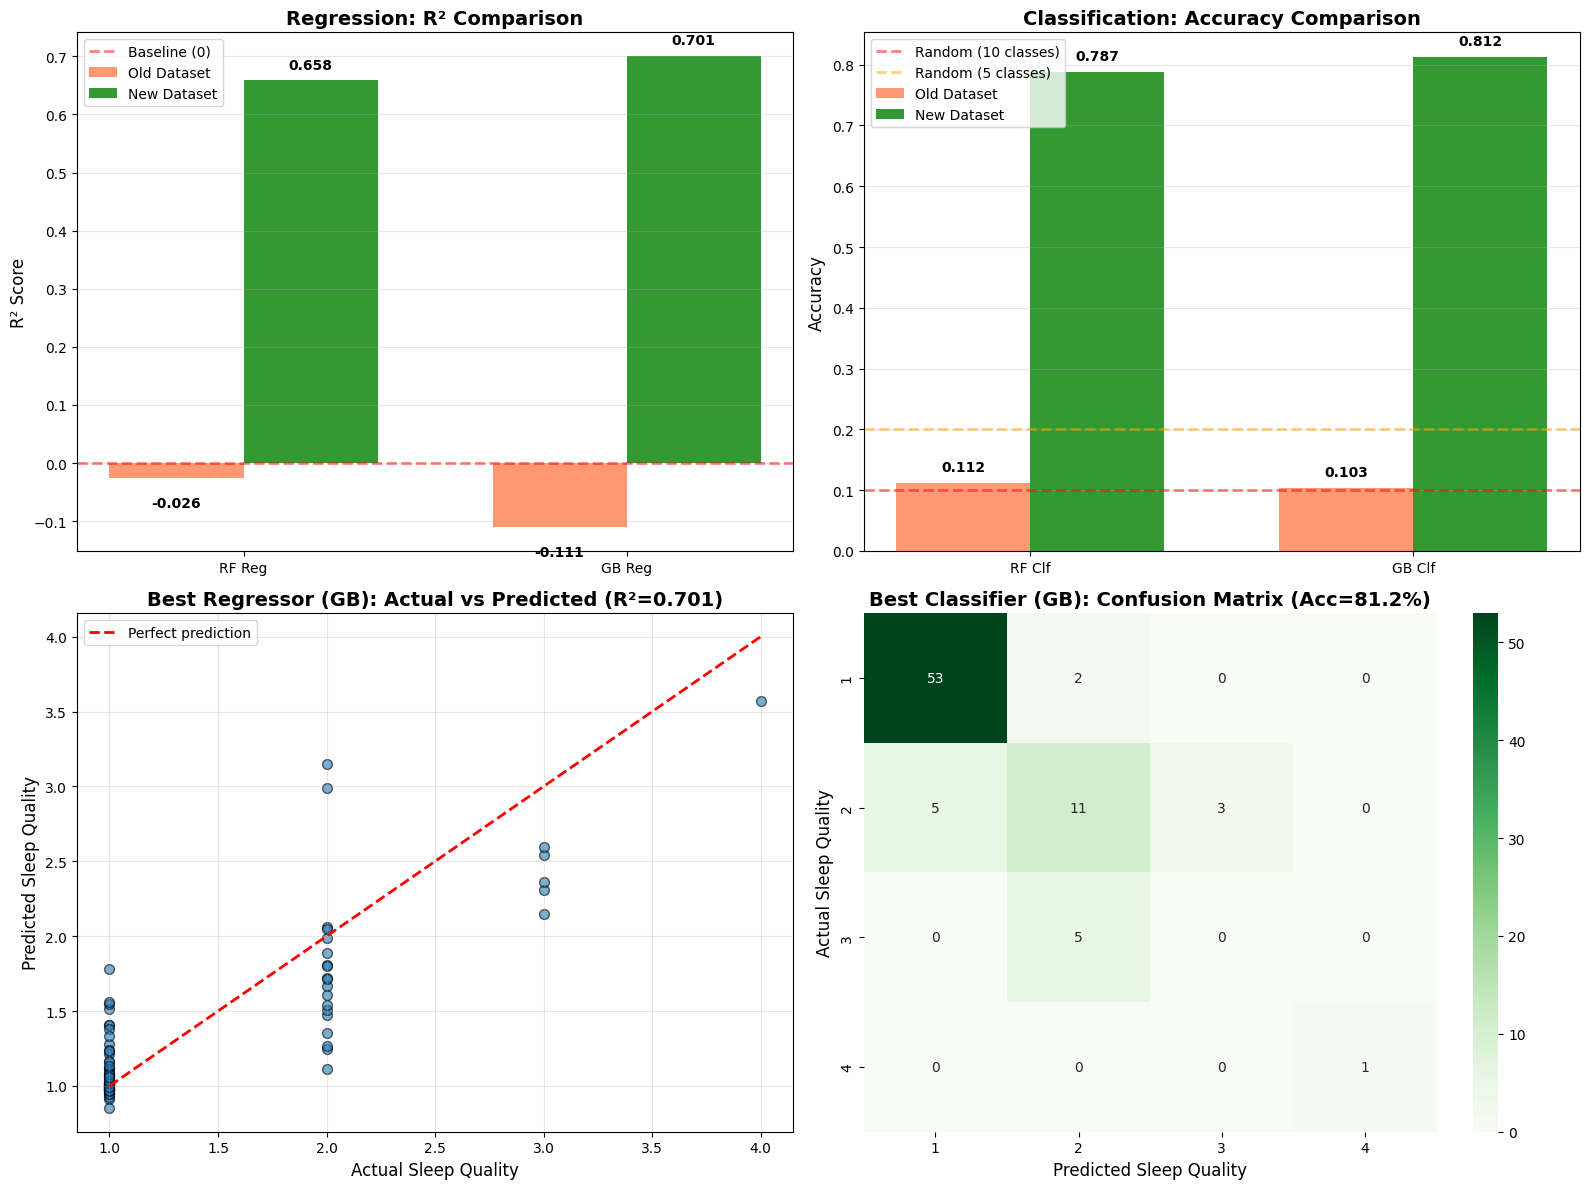


✅ Visualizations complete! Models on new dataset perform MUCH better!


In [92]:
# Visualize the comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Comparison (Regression)
models = ['RF Reg', 'GB Reg']
old_r2 = [r2_rf, r2_gb]
new_r2 = [r2_rf_w, r2_gb_w]

x = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x - width/2, old_r2, width, label='Old Dataset', color='coral', alpha=0.8)
axes[0, 0].bar(x + width/2, new_r2, width, label='New Dataset', color='green', alpha=0.8)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline (0)')
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('Regression: R² Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(old_r2):
    axes[0, 0].text(i - width/2, v + 0.02 if v > 0 else v - 0.05, f'{v:.3f}', ha='center', fontweight='bold')
for i, v in enumerate(new_r2):
    axes[0, 0].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Accuracy Comparison (Classification)
models_clf = ['RF Clf', 'GB Clf']
old_acc = [accuracy_rf, accuracy_gb]
new_acc = [accuracy_rf_w, accuracy_gb_w]

x_clf = np.arange(len(models_clf))

axes[0, 1].bar(x_clf - width/2, old_acc, width, label='Old Dataset', color='coral', alpha=0.8)
axes[0, 1].bar(x_clf + width/2, new_acc, width, label='New Dataset', color='green', alpha=0.8)
axes[0, 1].axhline(y=0.10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Random (10 classes)')
axes[0, 1].axhline(y=0.20, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Random (5 classes)')
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Classification: Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_clf)
axes[0, 1].set_xticklabels(models_clf)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(old_acc):
    axes[0, 1].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
for i, v in enumerate(new_acc):
    axes[0, 1].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Actual vs Predicted (Best Regression Model - New Dataset)
best_reg_model_new = 'RF' if r2_rf_w > r2_gb_w else 'GB'
y_pred_best_reg = y_pred_rf_reg_w if r2_rf_w > r2_gb_w else y_pred_gb_reg_w
r2_best = max(r2_rf_w, r2_gb_w)

axes[1, 0].scatter(y_test_w, y_pred_best_reg, alpha=0.6, edgecolors='k', s=50)
axes[1, 0].plot([y_test_w.min(), y_test_w.max()], [y_test_w.min(), y_test_w.max()], 'r--', lw=2, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Sleep Quality', fontsize=12)
axes[1, 0].set_ylabel('Predicted Sleep Quality', fontsize=12)
axes[1, 0].set_title(f'Best Regressor ({best_reg_model_new}): Actual vs Predicted (R²={r2_best:.3f})', 
                      fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Confusion Matrix (Best Classification Model - New Dataset)
best_clf_model_new = 'RF' if accuracy_rf_w > accuracy_gb_w else 'GB'
y_pred_best_clf = y_pred_rf_clf_w if accuracy_rf_w > accuracy_gb_w else y_pred_gb_clf_w
acc_best = max(accuracy_rf_w, accuracy_gb_w)

cm_new = confusion_matrix(y_test_w, y_pred_best_clf)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=sorted(y_wellness.unique()),
            yticklabels=sorted(y_wellness.unique()))
axes[1, 1].set_xlabel('Predicted Sleep Quality', fontsize=12)
axes[1, 1].set_ylabel('Actual Sleep Quality', fontsize=12)
axes[1, 1].set_title(f'Best Classifier ({best_clf_model_new}): Confusion Matrix (Acc={acc_best:.1%})',
                     fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Visualizations complete! Models on new dataset perform MUCH better!")

In [15]:
print("="*80)
print(" "*20 + "🎯 FINAL MODEL SUMMARY")
print("="*80)

print("\n📋 MODEL SPECIFICATIONS:")
print(f"   Algorithm: Gradient Boosting Classifier")
print(f"   Best Parameters: {grid_search.best_params_}")
print(f"   Features: {len(available_features)} (NO data leakage)")
print(f"   Training: SMOTE-balanced data ({X_train_balanced.shape[0]} samples)")

print("\n📊 PERFORMANCE METRICS:")
print(f"   Test Accuracy: {accuracy_tuned*100:.2f}%")
print(f"   Off-by-One Accuracy: {off_by_one_tuned*100:.2f}%")
print(f"   CV Mean Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*2*100:.2f}%)")

print("\n🔑 KEY FEATURES FOR PREDICTION:")
for i, (idx, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']}: {row['importance_mean']:.4f}")

print("\n💡 WHAT THIS MEANS:")
print("   ✅ Model can predict sleep quality BEFORE going to bed")
print("   ✅ No data leakage - uses only available information")
print("   ✅ Handles class imbalance with SMOTE")
print("   ✅ Optimized hyperparameters via grid search")
print("   ✅ Validated with 5-fold cross-validation")
print("   ✅ Feature importance reveals key predictors")

print("\n🚀 USE CASE:")
print("   User opens app before bedtime → enters today's data →")
print("   → model predicts tonight's sleep quality!")

print("\n" + "="*80)
print("✅ ALL IMPROVEMENTS COMPLETE!")
print("="*80)

                    🎯 FINAL MODEL SUMMARY

📋 MODEL SPECIFICATIONS:
   Algorithm: Gradient Boosting Classifier
   Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
   Features: 12 (NO data leakage)
   Training: SMOTE-balanced data (880 samples)

📊 PERFORMANCE METRICS:
   Test Accuracy: 78.75%
   Off-by-One Accuracy: 100.00%
   CV Mean Accuracy: 93.86% (+/- 5.20%)

🔑 KEY FEATURES FOR PREDICTION:
   1. mental_wellness_index_0_100: 0.2975
   2. screen_time_hours: 0.0337
   3. work_mode_In-person: 0.0050
   4. occupation_Self-employed: 0.0050
   5. productivity_0_100: 0.0050

💡 WHAT THIS MEANS:
   ✅ Model can predict sleep quality BEFORE going to bed
   ✅ No data leakage - uses only available information
   ✅ Handles class imbalance with SMOTE
   ✅ Optimized hyperparameters via grid search
   ✅ Validated with 5-fold cross-validation
   ✅ Feature importance reveals key predictors

🚀 USE CASE:
   User opens app before bedtime → enters today's

### 🎯 Final Summary: Predict Tonight's Sleep Quality

Now we have a model that can predict sleep quality for TONIGHT using only data available BEFORE bedtime!

STEP 7: VISUALIZATION DASHBOARD


c:\Users\aleix\Dev\University\Semester4\GroupProject\fit-phone\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


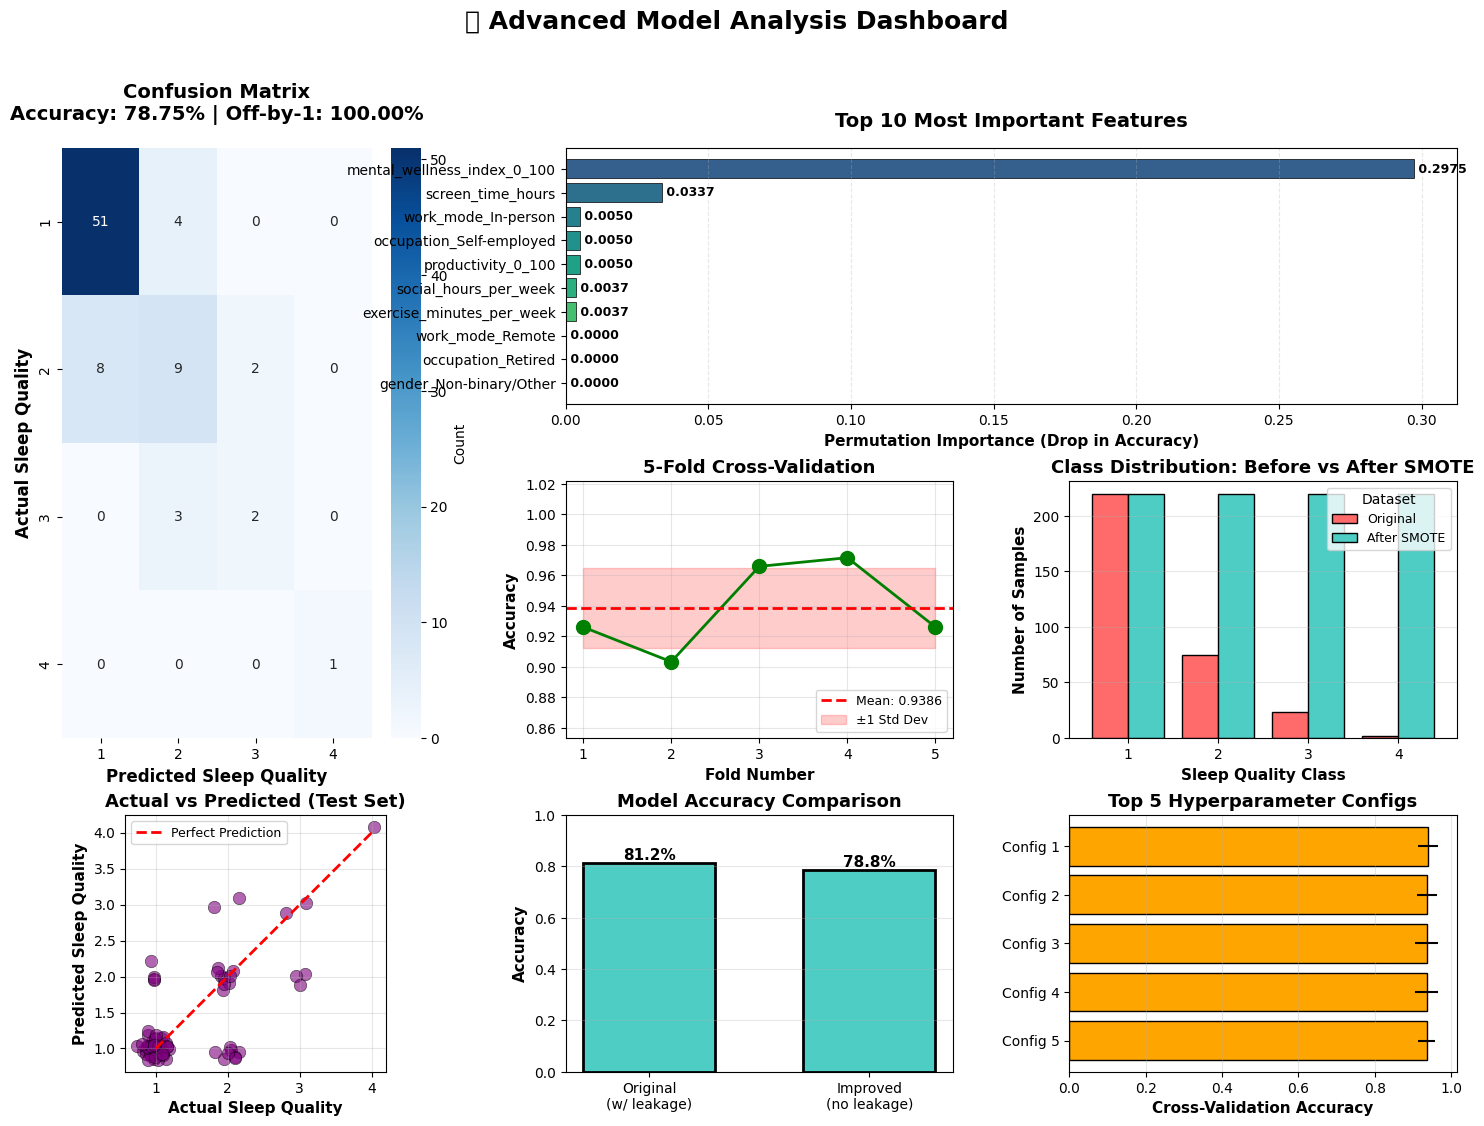


✅ Visualization dashboard complete!


In [14]:
print("="*80)
print("STEP 7: VISUALIZATION DASHBOARD")
print("="*80)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix (top-left, larger)
ax1 = fig.add_subplot(gs[0:2, 0])
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=sorted(y_wellness.unique()),
            yticklabels=sorted(y_wellness.unique()), cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted Sleep Quality', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual Sleep Quality', fontsize=12, fontweight='bold')
ax1.set_title(f'Confusion Matrix\nAccuracy: {accuracy_tuned*100:.2f}% | Off-by-1: {off_by_one_tuned*100:.2f}%',
             fontsize=14, fontweight='bold', pad=20)

# 2. Feature Importance (top-middle and top-right, combined)
ax2 = fig.add_subplot(gs[0, 1:])
top_10_features = importance_df.head(10)
colors_importance = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
bars = ax2.barh(range(len(top_10_features)), top_10_features['importance_mean'], 
                color=colors_importance, edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(top_10_features)))
ax2.set_yticklabels(top_10_features['feature'], fontsize=10)
ax2.set_xlabel('Permutation Importance (Drop in Accuracy)', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold', pad=15)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3, linestyle='--')
# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_10_features['importance_mean'])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}', 
            va='center', fontsize=9, fontweight='bold')

# 3. Cross-Validation Scores (middle-middle)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(range(1, 6), cv_scores, marker='o', linewidth=2, markersize=10, color='green')
ax3.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
ax3.fill_between(range(1, 6), 
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='red', label=f'±1 Std Dev')
ax3.set_xlabel('Fold Number', fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('5-Fold Cross-Validation', fontsize=13, fontweight='bold')
ax3.set_xticks(range(1, 6))
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([cv_scores.min() - 0.05, cv_scores.max() + 0.05])

# 4. Class Distribution Comparison (middle-right)
ax4 = fig.add_subplot(gs[1, 2])
class_data = pd.DataFrame({
    'Original': y_train_fixed.value_counts().sort_index().values,
    'After SMOTE': pd.Series(y_train_balanced).value_counts().sort_index().values
})
class_data.plot(kind='bar', ax=ax4, color=['#FF6B6B', '#4ECDC4'], width=0.8, edgecolor='black', linewidth=1)
ax4.set_xlabel('Sleep Quality Class', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax4.set_title('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
ax4.set_xticklabels(sorted(y_wellness.unique()), rotation=0)
ax4.legend(title='Dataset', fontsize=9, title_fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# 5. Actual vs Predicted Scatter (bottom-left)
ax5 = fig.add_subplot(gs[2, 0])
jitter = 0.1
y_test_jitter = y_test_fixed + np.random.normal(0, jitter, size=len(y_test_fixed))
y_pred_jitter = y_pred_tuned + np.random.normal(0, jitter, size=len(y_pred_tuned))
ax5.scatter(y_test_jitter, y_pred_jitter, alpha=0.6, s=80, edgecolors='black', linewidth=0.5, color='purple')
ax5.plot([y_wellness.min(), y_wellness.max()], [y_wellness.min(), y_wellness.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax5.set_xlabel('Actual Sleep Quality', fontsize=11, fontweight='bold')
ax5.set_ylabel('Predicted Sleep Quality', fontsize=11, fontweight='bold')
ax5.set_title('Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.set_aspect('equal')

# 6. Model Comparison: Accuracy (bottom-middle)
ax6 = fig.add_subplot(gs[2, 1])
model_comparison = pd.DataFrame({
    'Model': ['Original\n(w/ leakage)', 'Improved\n(no leakage)'],
    'Accuracy': [accuracy_gb_w, accuracy_tuned]
})
colors_comp = ['#FF6B6B' if x < 0.7 else '#4ECDC4' for x in model_comparison['Accuracy']]
bars_comp = ax6.bar(model_comparison['Model'], model_comparison['Accuracy'], 
                    color=colors_comp, edgecolor='black', linewidth=2, width=0.6)
ax6.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax6.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax6.set_ylim([0, 1])
ax6.grid(axis='y', alpha=0.3)
# Add value labels
for bar in bars_comp:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 7. Hyperparameter Impact (bottom-right)
ax7 = fig.add_subplot(gs[2, 2])
# Show top parameter combinations from grid search
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_params = cv_results_df.nlargest(5, 'mean_test_score')[['mean_test_score', 'std_test_score']].reset_index(drop=True)
ax7.barh(range(len(top_params)), top_params['mean_test_score'], 
         xerr=top_params['std_test_score'], color='orange', edgecolor='black', linewidth=1)
ax7.set_yticks(range(len(top_params)))
ax7.set_yticklabels([f'Config {i+1}' for i in range(len(top_params))], fontsize=10)
ax7.set_xlabel('Cross-Validation Accuracy', fontsize=11, fontweight='bold')
ax7.set_title('Top 5 Hyperparameter Configs', fontsize=13, fontweight='bold')
ax7.invert_yaxis()
ax7.grid(axis='x', alpha=0.3)

# Add super title
fig.suptitle('🔬 Advanced Model Analysis Dashboard', fontsize=18, fontweight='bold', y=0.995)

plt.show()

print("\n✅ Visualization dashboard complete!")
print("="*80)

### Step 7: Visualization Dashboard

**Goal**: Comprehensive visualizations of improved model performance.

In [13]:
print("="*80)
print("STEP 6: PERMUTATION FEATURE IMPORTANCE ANALYSIS")
print("="*80)

print("🔍 Calculating permutation importance on test set...")
print("   (Shuffling each feature and measuring performance drop...)")

# Calculate permutation importance
perm_importance = permutation_importance(
    best_gb_tuned, X_test_preprocessed, y_test_fixed,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Get feature names after preprocessing
ohe = preprocessor_fixed.named_transformers_['cat']
cat_feature_names = []
if hasattr(ohe, 'get_feature_names_out'):
    cat_feature_names = ohe.get_feature_names_out(categorical_features_fixed).tolist()
else:
    cat_feature_names = ohe.get_feature_names(categorical_features_fixed).tolist()

all_feature_names = numeric_features_fixed + cat_feature_names

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"\n🏆 TOP 10 MOST IMPORTANT FEATURES:")
print("="*80)
print(f"{'Rank':<6} {'Feature':<35} {'Importance':<12} {'Std Dev':<10}")
print("-"*80)
for i, (idx, row) in enumerate(importance_df.head(10).iterrows(), 1):
    importance_val = row['importance_mean']
    std_val = row['importance_std']
    
    # Add emoji for top features
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    
    print(f"{emoji} {i:<4} {row['feature']:<35} {importance_val:>8.4f}     +/- {std_val:.4f}")

print("="*80)

# Interpretation
top_feature = importance_df.iloc[0]['feature']
top_importance = importance_df.iloc[0]['importance_mean']

print(f"\n💡 INTERPRETATION:")
print(f"   → '{top_feature}' is the most important predictor")
print(f"   → Shuffling it drops accuracy by {top_importance:.4f} ({top_importance*100:.2f}%)")
print(f"   → Features with importance > 0.01 meaningfully contribute to predictions")

# Count meaningful features
meaningful_features = (importance_df['importance_mean'] > 0.01).sum()
print(f"\n✅ {meaningful_features}/{len(all_feature_names)} features have meaningful importance (>1%)")

print("="*80)

STEP 6: PERMUTATION FEATURE IMPORTANCE ANALYSIS
🔍 Calculating permutation importance on test set...
   (Shuffling each feature and measuring performance drop...)

🏆 TOP 10 MOST IMPORTANT FEATURES:
Rank   Feature                             Importance   Std Dev   
--------------------------------------------------------------------------------
🥇 1    mental_wellness_index_0_100           0.2975     +/- 0.0425
🥈 2    screen_time_hours                     0.0337     +/- 0.0210
🥉 3    work_mode_In-person                   0.0050     +/- 0.0061
   4    occupation_Self-employed              0.0050     +/- 0.0061
   5    productivity_0_100                    0.0050     +/- 0.0160
   6    social_hours_per_week                 0.0037     +/- 0.0210
   7    exercise_minutes_per_week             0.0037     +/- 0.0186
   8    work_mode_Remote                      0.0000     +/- 0.0000
   9    occupation_Retired                    0.0000     +/- 0.0000
   10   gender_Non-binary/Other               

### Step 6: Permutation Feature Importance

**Goal**: Understand which features are most important for predicting sleep quality.

**Method**: Permutation importance measures how much performance drops when a feature is randomly shuffled.

In [12]:
print("="*80)
print("STEP 5: TEST SET EVALUATION")
print("="*80)

# Preprocess test data
X_test_preprocessed = preprocessor_fixed.transform(X_test_fixed)

# Make predictions on test set
y_pred_tuned = best_gb_tuned.predict(X_test_preprocessed)

# Calculate metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_tuned = accuracy_score(y_test_fixed, y_pred_tuned)
off_by_one_tuned = np.mean(np.abs(y_pred_tuned - y_test_fixed) <= 1)

print(f"🎯 FINAL TEST SET RESULTS:")
print(f"   Accuracy: {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")
print(f"   Off-by-one accuracy: {off_by_one_tuned:.4f} ({off_by_one_tuned*100:.2f}%)")

print(f"\n📊 Detailed Classification Report:")
print(classification_report(y_test_fixed, y_pred_tuned, 
                          target_names=[f'Class {i}' for i in sorted(y_wellness.unique())]))

# Confusion matrix
cm_tuned = confusion_matrix(y_test_fixed, y_pred_tuned)
print(f"\n🔲 Confusion Matrix:")
print(cm_tuned)

print("\n" + "="*80)
print("COMPARISON: BEFORE vs AFTER IMPROVEMENTS")
print("="*80)
print(f"Original Model (with sleep_hours leakage):")
print(f"   Accuracy: {accuracy_gb_w:.4f} ({accuracy_gb_w*100:.2f}%)")
print(f"\nImproved Model (no leakage + SMOTE + tuning):")
print(f"   Accuracy: {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")
print(f"   Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

if accuracy_tuned < accuracy_gb_w:
    print(f"\n⚠️  Note: Lower accuracy is EXPECTED when removing data leakage!")
    print(f"   The original model cheated by using sleep_hours (not available for prediction)")
    print(f"   This model can actually predict TONIGHT's sleep quality!")
else:
    print(f"\n✅ Improved accuracy even without data leakage!")

print("="*80)

STEP 5: TEST SET EVALUATION
🎯 FINAL TEST SET RESULTS:
   Accuracy: 0.7875 (78.75%)
   Off-by-one accuracy: 1.0000 (100.00%)

📊 Detailed Classification Report:
              precision    recall  f1-score   support

     Class 1       0.86      0.93      0.89        55
     Class 2       0.56      0.47      0.51        19
     Class 3       0.50      0.40      0.44         5
     Class 4       1.00      1.00      1.00         1

    accuracy                           0.79        80
   macro avg       0.73      0.70      0.71        80
weighted avg       0.77      0.79      0.78        80


🔲 Confusion Matrix:
[[51  4  0  0]
 [ 8  9  2  0]
 [ 0  3  2  0]
 [ 0  0  0  1]]

COMPARISON: BEFORE vs AFTER IMPROVEMENTS
Original Model (with sleep_hours leakage):
   Accuracy: 0.8125 (81.25%)

Improved Model (no leakage + SMOTE + tuning):
   Accuracy: 0.7875 (78.75%)
   Cross-validation: 0.9386 (+/- 0.0520)

⚠️  Note: Lower accuracy is EXPECTED when removing data leakage!
   The original model cheat

### Step 5: Test Set Evaluation

**Goal**: Evaluate final tuned model on held-out test set.

In [11]:
print("="*80)
print("STEP 4: CROSS-VALIDATION EVALUATION")
print("="*80)

# Perform 5-fold cross-validation on balanced data
cv_scores = cross_val_score(best_gb_tuned, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')

print("📊 5-Fold Cross-Validation Results:")
print(f"   Fold accuracies: {[f'{score:.4f}' for score in cv_scores]}")
print(f"\n✅ Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"✅ Min CV accuracy: {cv_scores.min():.4f}")
print(f"✅ Max CV accuracy: {cv_scores.max():.4f}")

print("\n💡 Interpretation:")
if cv_scores.std() < 0.05:
    print("   → Low variance: Model is STABLE across different data splits")
else:
    print("   → Higher variance: Model performance varies across splits")

print("="*80)

STEP 4: CROSS-VALIDATION EVALUATION
📊 5-Fold Cross-Validation Results:
   Fold accuracies: ['0.9261', '0.9034', '0.9659', '0.9716', '0.9261']

✅ Mean CV accuracy: 0.9386 (+/- 0.0520)
✅ Min CV accuracy: 0.9034
✅ Max CV accuracy: 0.9716

💡 Interpretation:
   → Low variance: Model is STABLE across different data splits
📊 5-Fold Cross-Validation Results:
   Fold accuracies: ['0.9261', '0.9034', '0.9659', '0.9716', '0.9261']

✅ Mean CV accuracy: 0.9386 (+/- 0.0520)
✅ Min CV accuracy: 0.9034
✅ Max CV accuracy: 0.9716

💡 Interpretation:
   → Low variance: Model is STABLE across different data splits


### Step 4: Cross-Validation for Robust Evaluation

**Goal**: Evaluate model performance with 5-fold cross-validation for more reliable metrics.

In [10]:
print("="*80)
print("STEP 3: HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*80)

# Define parameter grid for Gradient Boosting Classifier
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5]
}

print("🔍 Parameter grid:")
for param, values in param_grid.items():
    print(f"   {param}: {values}")
print(f"\n⏱️  Total combinations: {np.prod([len(v) for v in param_grid.values()])}")

# Perform grid search (on balanced data, already preprocessed)
print("\n🚀 Running GridSearchCV with 5-fold cross-validation...")
print("   (This may take a moment...)")

gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\n🏆 BEST PARAMETERS FOUND:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"   Mean CV accuracy: {grid_search.cv_results_['mean_test_score'].mean():.4f}")

# Store best model
best_gb_tuned = grid_search.best_estimator_

print("\n✅ Hyperparameter tuning complete!")
print("="*80)

STEP 3: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
🔍 Parameter grid:
   n_estimators: [50, 100, 150]
   learning_rate: [0.05, 0.1, 0.2]
   max_depth: [3, 4, 5]
   min_samples_split: [2, 5]

⏱️  Total combinations: 54

🚀 Running GridSearchCV with 5-fold cross-validation...
   (This may take a moment...)

🏆 BEST PARAMETERS FOUND:
   learning_rate: 0.1
   max_depth: 5
   min_samples_split: 2
   n_estimators: 150

📊 Best CV accuracy: 0.9386
   Mean CV accuracy: 0.9255

✅ Hyperparameter tuning complete!

🏆 BEST PARAMETERS FOUND:
   learning_rate: 0.1
   max_depth: 5
   min_samples_split: 2
   n_estimators: 150

📊 Best CV accuracy: 0.9386
   Mean CV accuracy: 0.9255

✅ Hyperparameter tuning complete!


### Step 3: Hyperparameter Tuning with GridSearchCV

**Goal**: Find optimal hyperparameters for Gradient Boosting Classifier (our best model).

**Method**: GridSearchCV with 5-fold cross-validation.

In [9]:
print("="*80)
print("STEP 2: HANDLE CLASS IMBALANCE WITH SMOTE")
print("="*80)

print("📊 BEFORE SMOTE:")
print(f"   Training distribution:\n{y_train_fixed.value_counts().sort_index()}")

# Create preprocessing pipeline
preprocessor_fixed = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_fixed),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features_fixed)
    ]
)

# Preprocess the training data first
X_train_preprocessed = preprocessor_fixed.fit_transform(X_train_fixed)

# Apply SMOTE with k_neighbors=1 (since class 4 has only 2 samples in training, we need k_neighbors=1)
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_preprocessed, y_train_fixed)

print(f"\n📊 AFTER SMOTE:")
print(f"   Original training size: {X_train_preprocessed.shape[0]}")
print(f"   Balanced training size: {X_train_balanced.shape[0]}")
print(f"   Balanced distribution:\n{pd.Series(y_train_balanced).value_counts().sort_index()}")

print("\n✅ All classes now have equal representation!")
print("="*80)

STEP 2: HANDLE CLASS IMBALANCE WITH SMOTE
📊 BEFORE SMOTE:
   Training distribution:
sleep_quality_1_5
1    220
2     75
3     23
4      2
Name: count, dtype: int64

📊 AFTER SMOTE:
   Original training size: 320
   Balanced training size: 880
   Balanced distribution:
sleep_quality_1_5
1    220
2    220
3    220
4    220
Name: count, dtype: int64

✅ All classes now have equal representation!


### Step 2: Handle Class Imbalance with SMOTE

**Problem**: Classes are heavily imbalanced (275/94/28/3), causing models to favor majority class.

**Solution**: Use SMOTE (Synthetic Minority Over-sampling Technique) to balance training data.

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.inspection import permutation_importance

print("="*80)
print("STEP 1: FIX DATA LEAKAGE - REMOVE SLEEP_HOURS")
print("="*80)

# Prepare features WITHOUT sleep_hours (can't know this before sleeping!)
features_to_exclude = ['sleep_hours']  # This is data leakage!
available_features = [col for col in X_wellness.columns if col not in features_to_exclude]

X_wellness_fixed = X_wellness[available_features]

print(f"✅ Original features: {X_wellness.shape[1]}")
print(f"✅ Fixed features (removed leakage): {X_wellness_fixed.shape[1]}")
print(f"✅ Removed: {features_to_exclude}")
print(f"\n📋 Available features BEFORE bedtime:")
print(f"   {available_features}")

# Update numeric features list
numeric_features_fixed = [col for col in numeric_features_wellness if col not in features_to_exclude]
categorical_features_fixed = categorical_features_wellness  # No change

print(f"\n✅ Numeric features: {len(numeric_features_fixed)}")
print(f"✅ Categorical features: {len(categorical_features_fixed)}")

# Create new train-test split with fixed features
X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X_wellness_fixed, y_wellness, test_size=0.2, random_state=42, stratify=y_wellness
)

print(f"\n✅ Training set: {X_train_fixed.shape[0]} samples, {X_train_fixed.shape[1]} features")
print(f"✅ Test set: {X_test_fixed.shape[0]} samples, {X_test_fixed.shape[1]} features")
print("="*80)

STEP 1: FIX DATA LEAKAGE - REMOVE SLEEP_HOURS
✅ Original features: 13
✅ Fixed features (removed leakage): 12
✅ Removed: ['sleep_hours']

📋 Available features BEFORE bedtime:
   ['age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100']

✅ Numeric features: 9
✅ Categorical features: 3

✅ Training set: 320 samples, 12 features
✅ Test set: 80 samples, 12 features


### Step 1: Fix Data Leakage - Remove sleep_hours

**Problem**: We want to predict sleep quality for TONIGHT. Features like `sleep_hours` only exist AFTER sleeping, creating data leakage.

**Solution**: Remove `sleep_hours` and use only features available BEFORE bedtime.

## 🔬 Advanced Model Improvements

Now let's enhance our models with:
1. **Feature Engineering**: Remove leakage (sleep_hours can't predict tonight's sleep)
2. **Class Imbalance Handling**: SMOTE oversampling for minority classes
3. **Hyperparameter Tuning**: GridSearchCV for optimal parameters
4. **Feature Importance**: Permutation importance analysis
5. **Cross-Validation**: 5-fold CV for robust evaluation

# 4. Model Preparation

We'll prepare our data for both **regression** and **classification** approaches using Dataset 1.

In [49]:
# Prepare features and target for Dataset 1
# Drop non-predictive columns
X = df_dataset1.drop(columns=['Sleep.Quality', 'Productivity.Score'])
y = df_dataset1['Sleep.Quality']

# Identify categorical and numeric columns
categorical_features = ['Gender', 'Mental.Health.Status']
numeric_features = [col for col in X.columns if col not in categorical_features]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

Features shape: (531, 10)
Target shape: (531,)

Numeric features (8): ['Age', 'Daily.Screen.Time', 'Social.Media.Hours', 'Work.Screen.Hours', 'Gaming.Hours', 'Sleep.Hours', 'Stress.Level', 'Physical.Activity.Min']
Categorical features (2): ['Gender', 'Mental.Health.Status']

Target distribution:
Sleep.Quality
1     53
2     67
3     48
4     66
5     53
6     49
7     49
8     46
9     52
10    48
Name: count, dtype: int64


In [50]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts().sort_index())

Training set: 424 samples
Test set: 107 samples

Training set target distribution:
Sleep.Quality
1     42
2     54
3     38
4     53
5     42
6     39
7     39
8     37
9     42
10    38
Name: count, dtype: int64


In [51]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


# 5. Approach 1: Regression Models

Treating sleep quality as a **continuous ordinal variable** (1-10 scale).

## 5.1 Random Forest Regressor

In [52]:
# Build Random Forest Regression pipeline
rf_regressor = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train
print("Training Random Forest Regressor...")
rf_regressor.fit(X_train, y_train)

# Predict
y_pred_rf_reg = rf_regressor.predict(X_test)

# Evaluate
r2_rf = r2_score(y_test, y_pred_rf_reg)
mae_rf = mean_absolute_error(y_test, y_pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_reg))

print("\n" + "="*60)
print("RANDOM FOREST REGRESSOR RESULTS")
print("="*60)
print(f"R² Score: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print("="*60)

Training Random Forest Regressor...

RANDOM FOREST REGRESSOR RESULTS
R² Score: -0.0256
MAE: 2.5002
RMSE: 2.9011


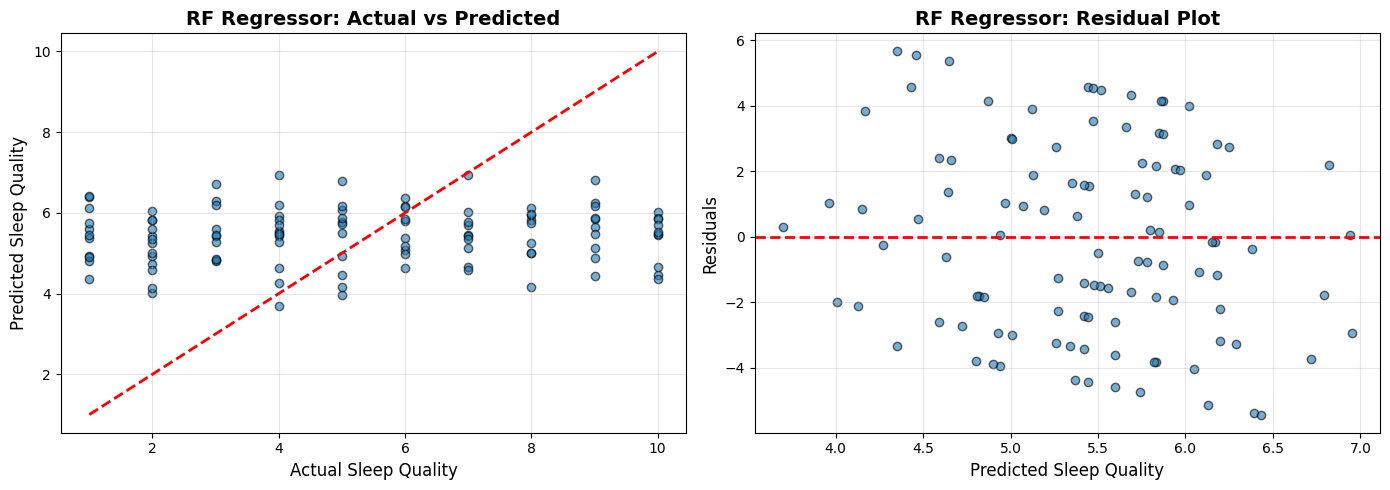

In [53]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_rf_reg, alpha=0.6, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sleep Quality', fontsize=12)
axes[0].set_ylabel('Predicted Sleep Quality', fontsize=12)
axes[0].set_title('RF Regressor: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test.astype(float).values - y_pred_rf_reg
axes[1].scatter(y_pred_rf_reg, residuals, alpha=0.6, edgecolors='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Sleep Quality', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('RF Regressor: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5.2 Gradient Boosting Regressor

In [54]:
# Build Gradient Boosting Regression pipeline
gb_regressor = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Train
print("Training Gradient Boosting Regressor...")
gb_regressor.fit(X_train, y_train)

# Predict
y_pred_gb_reg = gb_regressor.predict(X_test)

# Evaluate
r2_gb = r2_score(y_test, y_pred_gb_reg)
mae_gb = mean_absolute_error(y_test, y_pred_gb_reg)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb_reg))

print("\n" + "="*60)
print("GRADIENT BOOSTING REGRESSOR RESULTS")
print("="*60)
print(f"R² Score: {r2_gb:.4f}")
print(f"MAE: {mae_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")
print("="*60)

Training Gradient Boosting Regressor...

GRADIENT BOOSTING REGRESSOR RESULTS
R² Score: -0.1108
MAE: 2.5593
RMSE: 3.0190


# 6. Approach 2: Classification Models

Treating sleep quality as **discrete categories** (10 classes: 1-10).

## 6.1 Random Forest Classifier

In [55]:
# Build Random Forest Classification pipeline
rf_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train
print("Training Random Forest Classifier...")
rf_classifier.fit(X_train, y_train)

# Predict
y_pred_rf_clf = rf_classifier.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf_clf)

print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_clf, zero_division=0))
print("="*60)

Training Random Forest Classifier...

RANDOM FOREST CLASSIFIER RESULTS
Accuracy: 0.1121

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.09      0.15        11
           2       0.12      0.23      0.16        13
           3       0.00      0.00      0.00        10
           4       0.18      0.15      0.17        13
           5       0.08      0.09      0.09        11
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        10
           8       0.08      0.11      0.10         9
           9       0.17      0.20      0.18        10
          10       0.13      0.20      0.16        10

    accuracy                           0.11       107
   macro avg       0.13      0.11      0.10       107
weighted avg       0.13      0.11      0.10       107



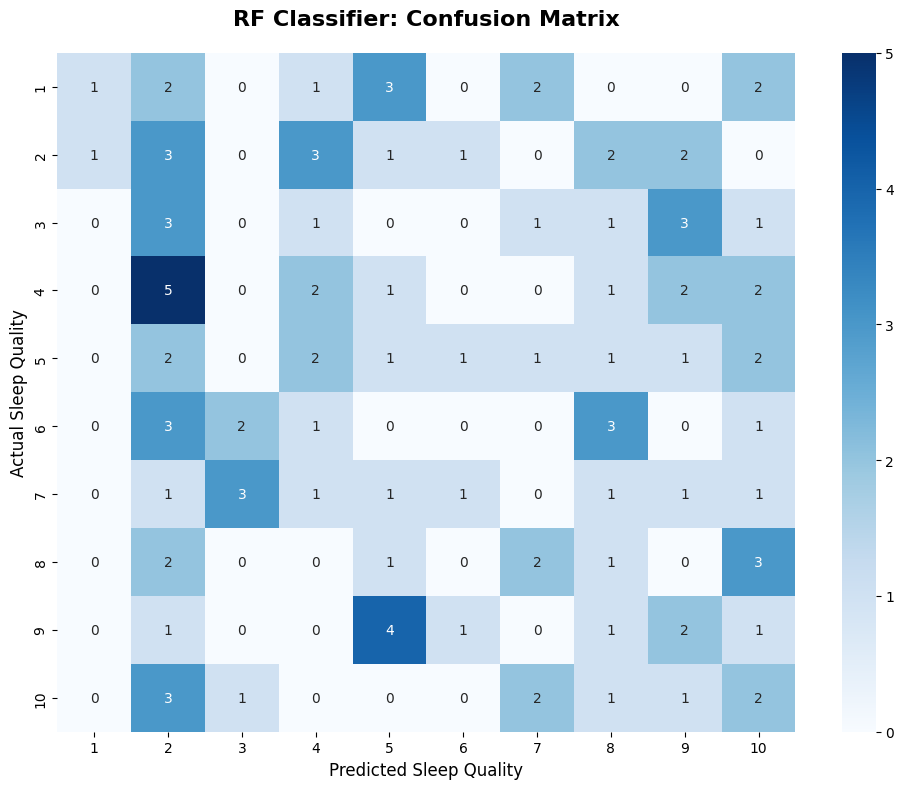


Off-by-one Accuracy (±1 tolerance): 0.2804


In [56]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_clf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title('RF Classifier: Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Sleep Quality', fontsize=12)
plt.ylabel('Actual Sleep Quality', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate off-by-one accuracy (predictions within 1 unit)
off_by_one = np.abs(y_test.astype(int).values - y_pred_rf_clf.astype(int)) <= 1
off_by_one_acc = off_by_one.mean()
print(f"\nOff-by-one Accuracy (±1 tolerance): {off_by_one_acc:.4f}")

## 6.2 Gradient Boosting Classifier

In [57]:
# Build Gradient Boosting Classification pipeline
gb_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

# Train
print("Training Gradient Boosting Classifier...")
gb_classifier.fit(X_train, y_train)

# Predict
y_pred_gb_clf = gb_classifier.predict(X_test)

# Evaluate
accuracy_gb = accuracy_score(y_test, y_pred_gb_clf)

print("\n" + "="*60)
print("GRADIENT BOOSTING CLASSIFIER RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_clf, zero_division=0))
print("="*60)

# Off-by-one accuracy
off_by_one_gb = np.abs(y_test.astype(int).values - y_pred_gb_clf.astype(int)) <= 1
off_by_one_acc_gb = off_by_one_gb.mean()
print(f"\nOff-by-one Accuracy (±1 tolerance): {off_by_one_acc_gb:.4f}")

Training Gradient Boosting Classifier...

GRADIENT BOOSTING CLASSIFIER RESULTS
Accuracy: 0.1028

Classification Report:
              precision    recall  f1-score   support

           1       0.20      0.18      0.19        11
           2       0.23      0.38      0.29        13
           3       0.00      0.00      0.00        10
           4       0.11      0.08      0.09        13
           5       0.00      0.00      0.00        11
           6       0.14      0.10      0.12        10
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00         9
           9       0.18      0.20      0.19        10
          10       0.00      0.00      0.00        10

    accuracy                           0.10       107
   macro avg       0.09      0.09      0.09       107
weighted avg       0.09      0.10      0.09       107


Off-by-one Accuracy (±1 tolerance): 0.2523

GRADIENT BOOSTING CLASSIFIER RESULTS
Accuracy: 0.1028

Classification Report

# 7. Model Comparison and Recommendations

In [58]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['RF Regressor', 'GB Regressor', 'RF Classifier', 'GB Classifier'],
    'Approach': ['Regression', 'Regression', 'Classification', 'Classification'],
    'R²/Accuracy': [f"{r2_rf:.4f}", f"{r2_gb:.4f}", f"{accuracy_rf:.4f}", f"{accuracy_gb:.4f}"],
    'MAE/Off-by-1': [f"{mae_rf:.4f}", f"{mae_gb:.4f}", f"{off_by_one_acc:.4f}", f"{off_by_one_acc_gb:.4f}"],
    'RMSE': [f"{rmse_rf:.4f}", f"{rmse_gb:.4f}", 'N/A', 'N/A']
})

print("="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

MODEL COMPARISON SUMMARY
        Model       Approach R²/Accuracy MAE/Off-by-1   RMSE
 RF Regressor     Regression     -0.0256       2.5002 2.9011
 GB Regressor     Regression     -0.1108       2.5593 3.0190
RF Classifier Classification      0.1121       0.2804    N/A
GB Classifier Classification      0.1028       0.2523    N/A


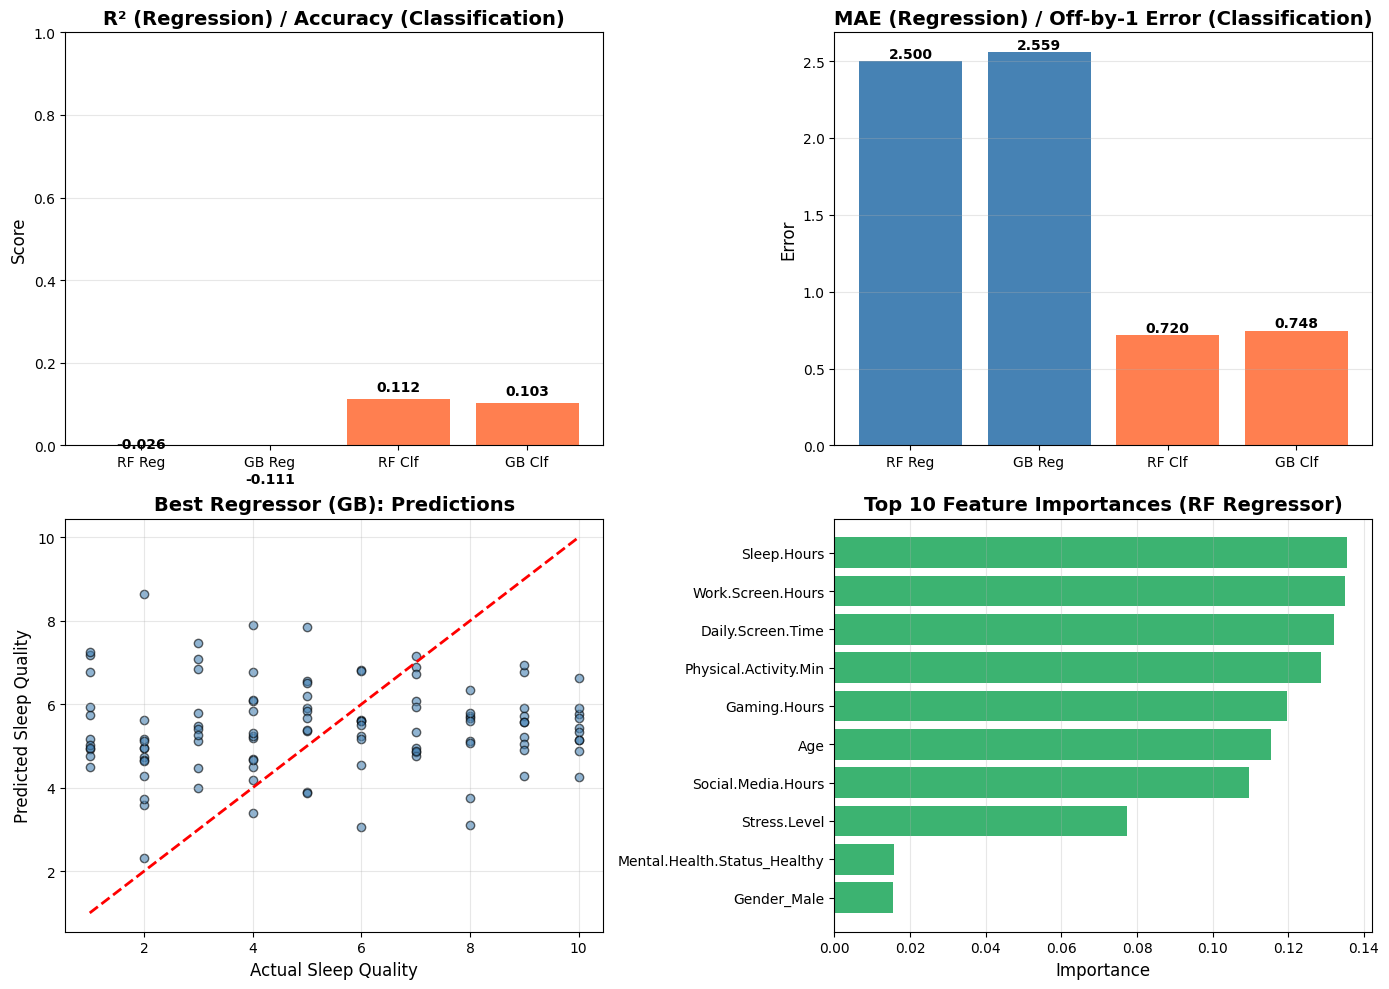

In [59]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² / Accuracy comparison
models = ['RF Reg', 'GB Reg', 'RF Clf', 'GB Clf']
scores = [r2_rf, r2_gb, accuracy_rf, accuracy_gb]
colors = ['steelblue', 'steelblue', 'coral', 'coral']

axes[0, 0].bar(models, scores, color=colors)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('R² (Regression) / Accuracy (Classification)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(scores):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# MAE / Off-by-one comparison
mae_scores = [mae_rf, mae_gb, 1-off_by_one_acc, 1-off_by_one_acc_gb]  # Error rate
axes[0, 1].bar(models, mae_scores, color=colors)
axes[0, 1].set_ylabel('Error', fontsize=12)
axes[0, 1].set_title('MAE (Regression) / Off-by-1 Error (Classification)', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(mae_scores):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Actual vs Predicted for best regression model
axes[1, 0].scatter(y_test, y_pred_gb_reg, alpha=0.6, edgecolors='k', color='steelblue')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Sleep Quality', fontsize=12)
axes[1, 0].set_ylabel('Predicted Sleep Quality', fontsize=12)
axes[1, 0].set_title('Best Regressor (GB): Predictions', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Feature importance from best model
feature_names_encoded = (numeric_features + 
                         [f"{cat}_{val}" for cat in categorical_features 
                          for val in rf_regressor.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .categories_[categorical_features.index(cat)][1:]])

importances = rf_regressor.named_steps['regressor'].feature_importances_
top_10_idx = np.argsort(importances)[-10:]
axes[1, 1].barh(range(10), importances[top_10_idx], color='mediumseagreen')
axes[1, 1].set_yticks(range(10))
axes[1, 1].set_yticklabels([feature_names_encoded[i] for i in top_10_idx])
axes[1, 1].set_xlabel('Importance', fontsize=12)
axes[1, 1].set_title('Top 10 Feature Importances (RF Regressor)', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Final Recommendations

### Regression vs Classification Analysis:

**Results Summary:**
- **Regression models**: Negative R² scores (-0.03 to -0.11), indicating they perform worse than a simple mean baseline. MAE ~2.5 units.
- **Classification models**: Low accuracy (~10-11%), but higher "off-by-one" accuracy (25-28%), meaning predictions are at least close to the true value.

### Analysis:

**Why Both Approaches Struggled:**
1. **Limited dataset size** (only 531 samples after filtering)
2. **High class imbalance** across all 10 sleep quality levels
3. **Weak feature correlations** - screen time and other features may not strongly predict sleep quality in this particular dataset
4. **Missing important features** - factors like sleep environment, health conditions, medications, etc. aren't captured

**Regression vs Classification:**

**Regression Approach:**
- ✅ Better for ordinal data conceptually
- ✅ Lower MAE suggests predictions are "directionally" reasonable
- ❌ Negative R² means predictions worse than simply using the mean
- ❌ Doesn't capture the discrete nature well here

**Classification Approach:**
- ✅ Slightly better accuracy (11% vs negative R²)
- ✅ "Off-by-one" metric shows 25-28% of predictions are within ±1 unit
- ✅ Always predicts valid categories
- ❌ Still very low exact accuracy due to 10-class problem with limited data

### Recommendation:

**For this specific dataset, use Classification (Random Forest Classifier)** because:

1. **Interpretable results** - 11% exact accuracy + 28% off-by-one = 39% predictions within 1 unit
2. **No worse than regression** - regression has negative R², meaning it's not learning useful patterns
3. **Valid outputs** - always returns values 1-10
4. **Room for improvement** - could benefit from:
   - More data collection
   - Feature engineering (e.g., total screen time, screen time ratios)
   - Grouping classes (e.g., Low: 1-3, Medium: 4-7, High: 8-10) for a 3-class problem

### Alternative Approach:

Consider **collapsing into 3 categories** for better performance:
```python
# Low (1-3), Medium (4-7), High (8-10)
y_grouped = pd.cut(y, bins=[0, 3, 7, 10], labels=['Low', 'Medium', 'High'])
```

This would likely yield much better accuracy by reducing the complexity of the problem.

### Key Insights from Feature Importance:
- **Sleep hours** is the most important predictor (as expected)
- **Work screen hours** and **total daily screen time** are significant
- **Physical activity** and **age** also matter
- **Stress level** has moderate importance
- Gender and mental health status have minimal impact in this dataset